# Model to Classify LaTeX Formulas
Notebook này xây dựng mô hình máy học để phân loại công thức toán học viết bằng LaTeX.

Quy trình:
1. **Import thư viện**
2. **Nạp dữ liệu** (datasheet đã xử lý)
3. **EDA** (khám phá dữ liệu)
4. **Tiền xử lý dữ liệu**
5. **Cân bằng dữ liệu**
6. **Trích xuất đặc trưng**
7. **Huấn luyện mô hình**
8. **Đánh giá mô hình**
9. **Dự đoán công thức mới**

In [17]:
# Import các thư viện cần thiết
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Thư viện xử lý văn bản
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# Các mô hình
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Đánh giá
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.calibration import CalibratedClassifierCV

# Đặt style cho matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Đặt seed cho tái lập kết quả
np.random.seed(42)

print("✅ Đã import các thư viện thành công!")

✅ Đã import các thư viện thành công!


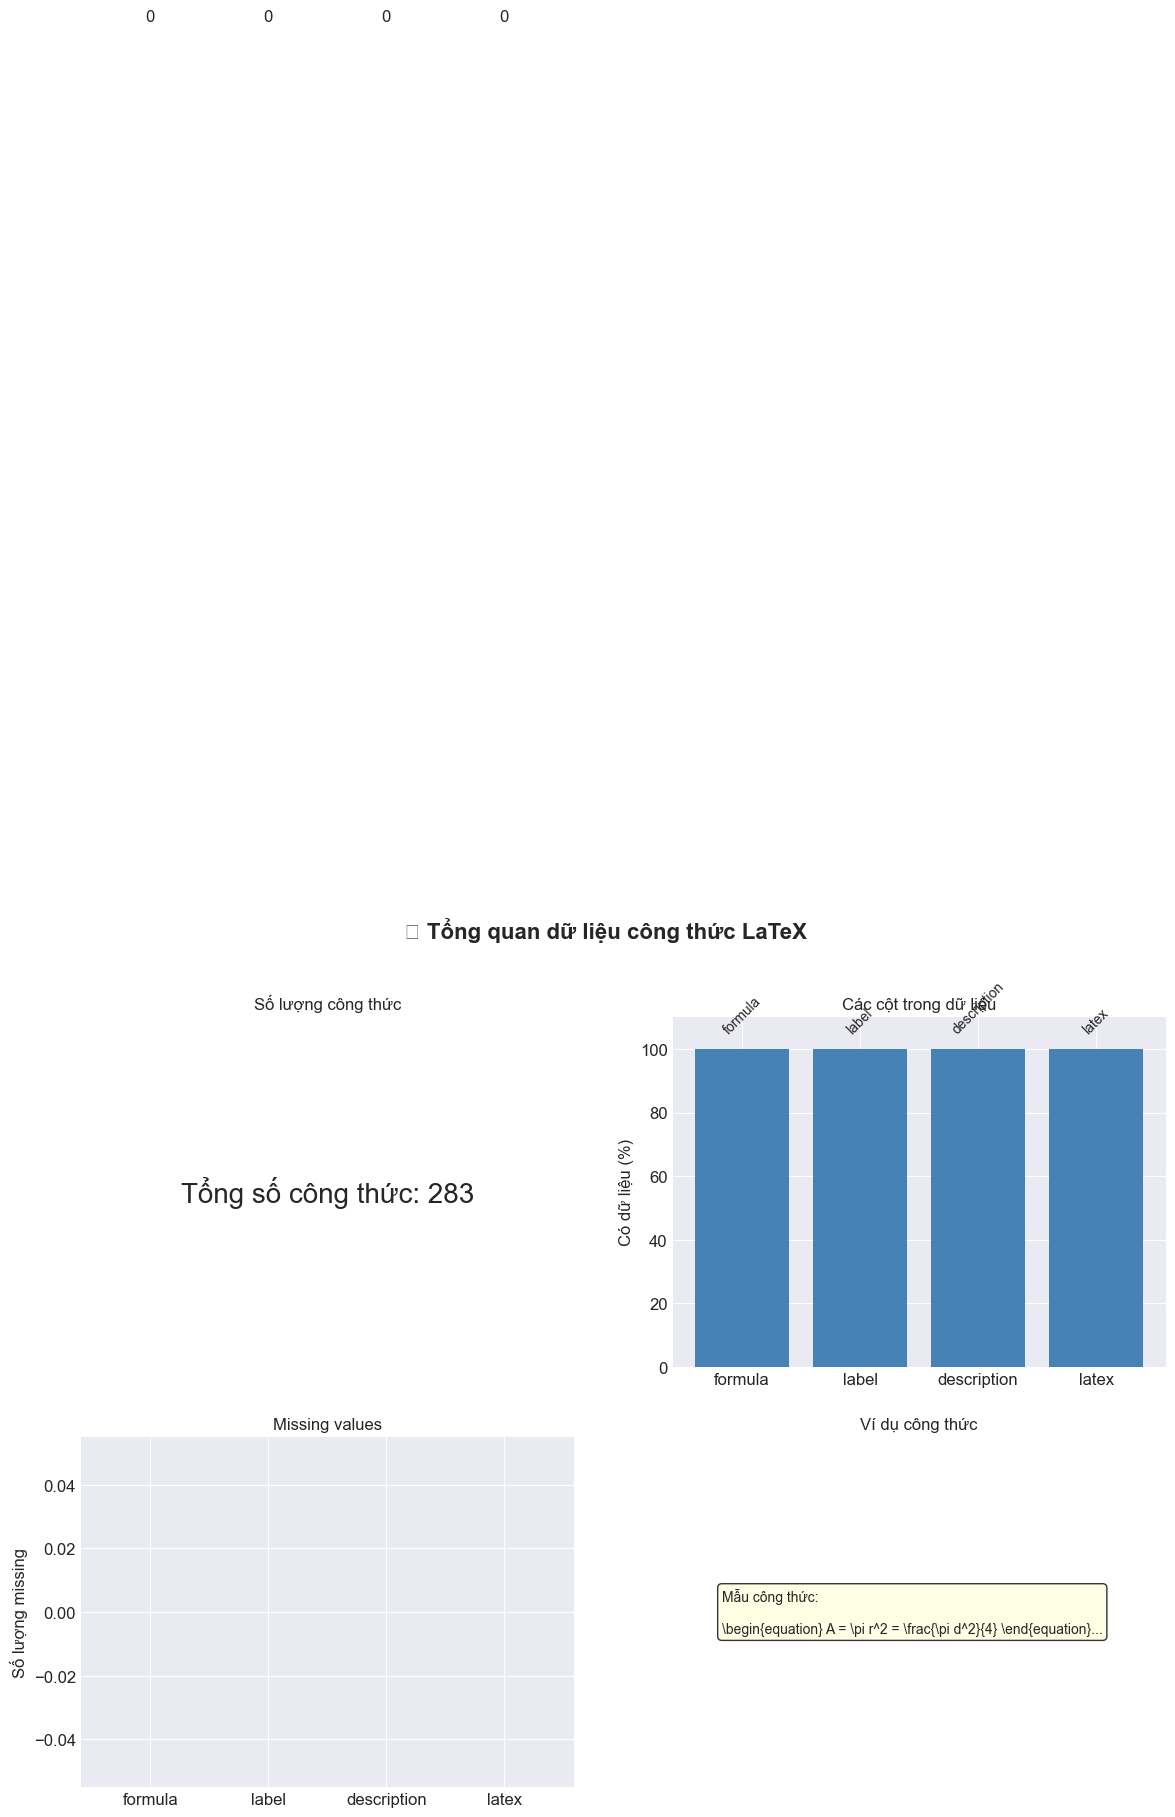


✅ Đã nạp 283 công thức từ file JSON


,formula,label,description,latex
0,\begin{equation} A = \pi r^2 = \frac{\pi d^2}{...,Geometry,Area of a circle,\begin{equation} A = \pi r^2 = \frac{\pi d^2}{...
1,\begin{equation} A = b h \end{equation},Geometry,Area of a parallelogram,\begin{equation} A = b h \end{equation}
2,\begin{equation} A = l w \end{equation},Geometry,Area of a rectangle,\begin{equation} A = l w \end{equation}
3,"\begin{equation} A = \frac{3 \sqrt{3}}{2} \, s...",Geometry,Area of a regular hexagon,"\begin{equation} A = \frac{3 \sqrt{3}}{2} \, s..."
4,\begin{equation} A = 2 \left( 1 + \sqrt{2} \ri...,Geometry,Area of a regular octagon,\begin{equation} A = 2 \left( 1 + \sqrt{2} \ri...


In [18]:
# Đường dẫn file
data_path = r"D:\Hoc_tap\The-math-latex--craw-and-ML\formulas\datasheet.json"

# Load JSON
with open(data_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# === VISUALIZATION 1: Tổng quan dữ liệu ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Tổng quan dữ liệu công thức LaTeX', fontsize=16, fontweight='bold')

# Số lượng bản ghi
axes[0, 0].text(0.5, 0.5, f'Tổng số công thức: {len(df)}', 
                ha='center', va='center', fontsize=20, transform=axes[0, 0].transAxes)
axes[0, 0].set_title('Số lượng công thức', fontsize=12)
axes[0, 0].axis('off')

# Các cột có sẵn
axes[0, 1].bar(df.columns, [100] * len(df.columns), color='steelblue')
axes[0, 1].set_title('Các cột trong dữ liệu', fontsize=12)
axes[0, 1].set_ylabel('Có dữ liệu (%)')
axes[0, 1].set_ylim(0, 110)
for i, col in enumerate(df.columns):
    axes[0, 1].text(i, 105, col, ha='center', fontsize=10, rotation=45)

# Missing values
missing = df.isnull().sum()
axes[1, 0].bar(missing.index, missing.values, color=['green' if v==0 else 'red' for v in missing])
axes[1, 0].set_title('Missing values', fontsize=12)
axes[1, 0].set_ylabel('Số lượng missing')
for i, v in enumerate(missing):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center')

# Sample công thức
sample_formula = df.iloc[0]['formula'][:100]
axes[1, 1].text(0.1, 0.5, f'Mẫu công thức:\n\n{sample_formula}...', 
                ha='left', va='center', fontsize=10, transform=axes[1, 1].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
axes[1, 1].set_title('Ví dụ công thức', fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ Đã nạp {len(df)} công thức từ file JSON")
df.head()

## 1.1 Khám phá dữ liệu (EDA)
- Xem số lượng công thức, số nhãn, phân phối nhãn.
- Xem ví dụ một số công thức và nhãn.
- Kiểm tra độ dài công thức, phát hiện giá trị thiếu hoặc bất thường.

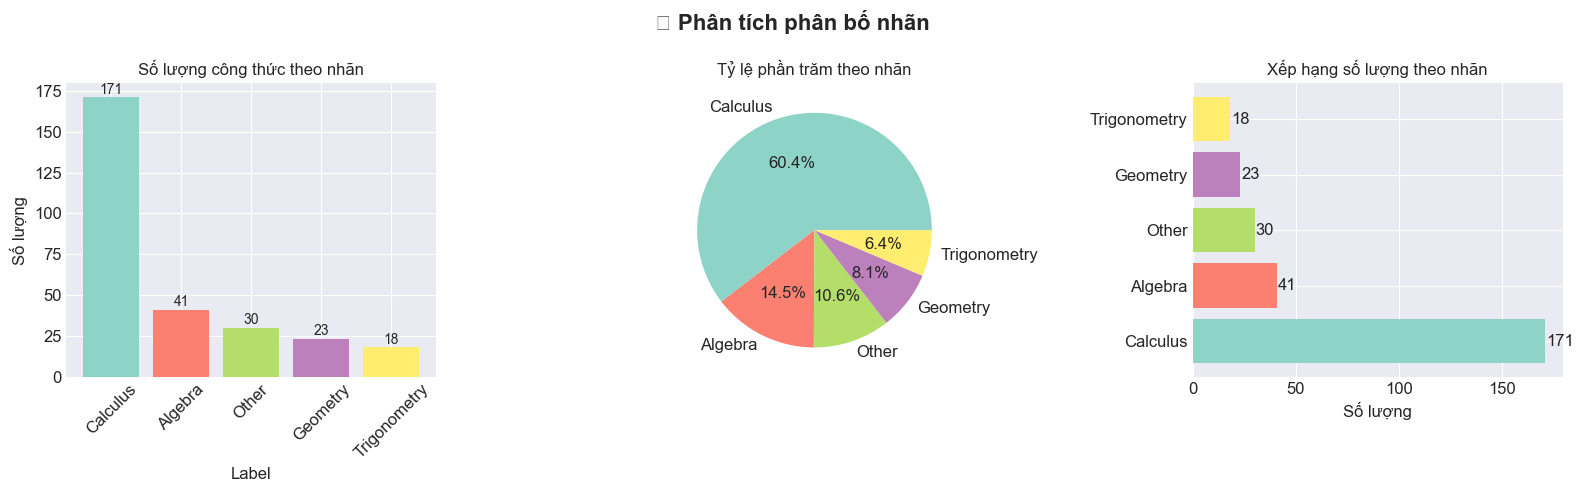


📊 Thống kê chi tiết nhãn:
Calculus            :  171 công thức (60.42%)
Algebra             :   41 công thức (14.49%)
Other               :   30 công thức (10.60%)
Geometry            :   23 công thức ( 8.13%)
Trigonometry        :   18 công thức ( 6.36%)


In [19]:
# === VISUALIZATION 2: Phân bố nhãn ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📈 Phân tích phân bố nhãn', fontsize=16, fontweight='bold')

# Bar chart
label_counts = df['label'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(label_counts)))
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title('Số lượng công thức theo nhãn', fontsize=12)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=45)

# Thêm số liệu trên cột
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontsize=10)

# Pie chart
wedges, texts, autotexts = axes[1].pie(label_counts.values, labels=label_counts.index, 
                                        autopct='%1.1f%%', colors=colors)
axes[1].set_title('Tỷ lệ phần trăm theo nhãn', fontsize=12)

# Treemap-like representation (horizontal bar)
y_pos = np.arange(len(label_counts))
axes[2].barh(y_pos, label_counts.values, color=colors)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(label_counts.index)
axes[2].set_title('Xếp hạng số lượng theo nhãn', fontsize=12)
axes[2].set_xlabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[2].text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

# Thống kê chi tiết
print("\n📊 Thống kê chi tiết nhãn:")
print("=" * 50)
for label, count in label_counts.items():
    percentage = count / len(df) * 100
    print(f"{label:20s}: {count:4d} công thức ({percentage:5.2f}%)")

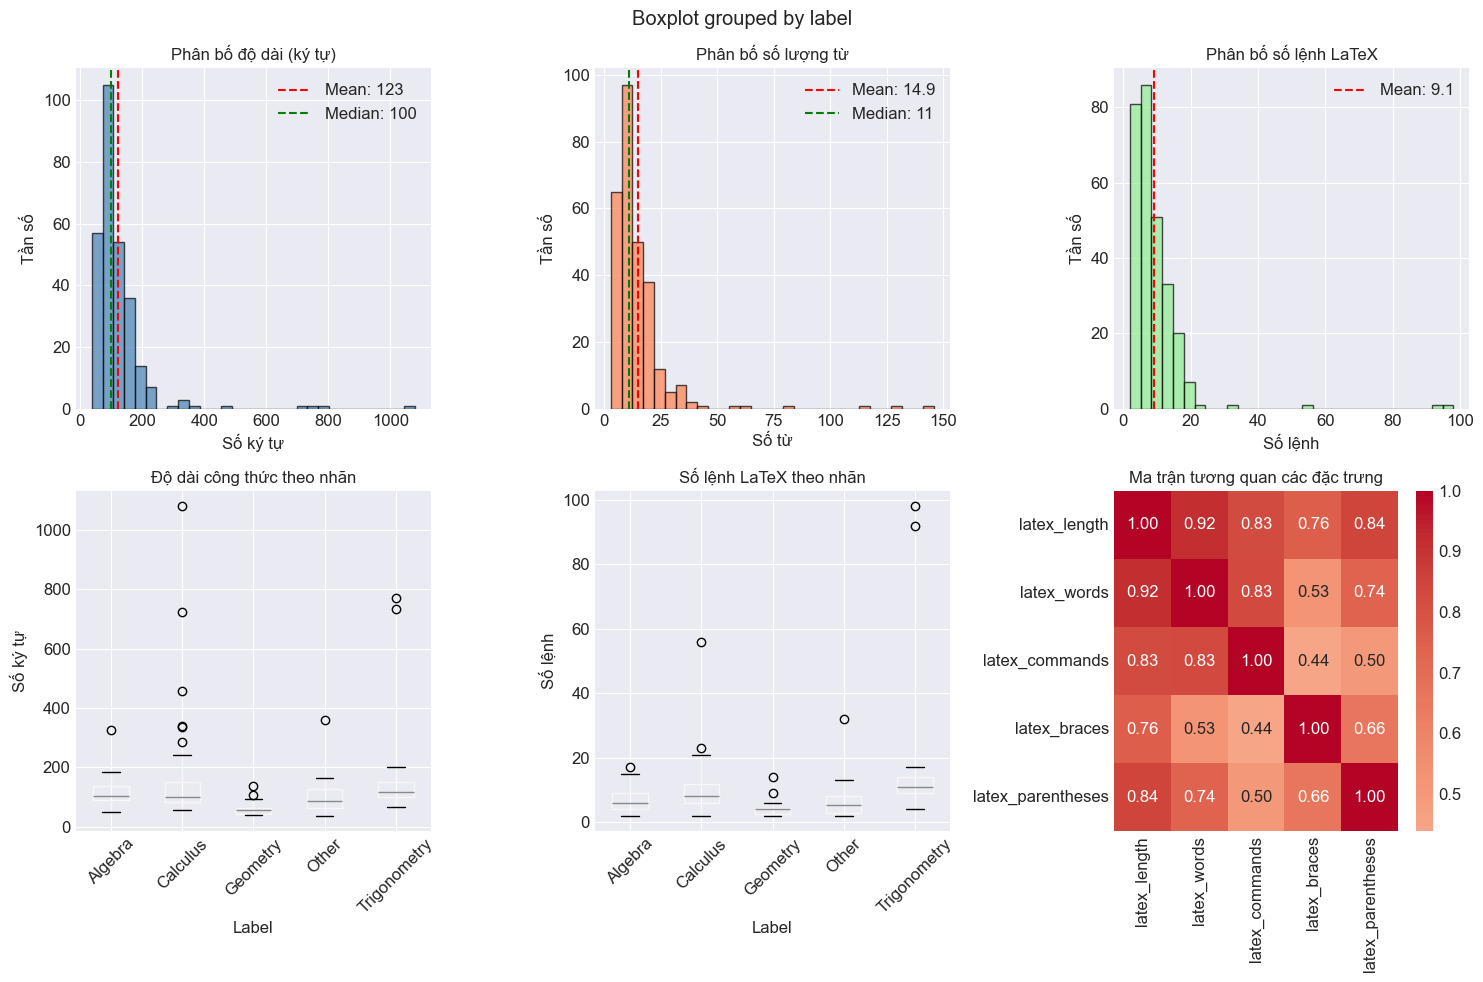


📊 Thống kê độ dài công thức:
   - Độ dài trung bình: 122.94 ký tự
   - Độ dài trung vị: 100.00 ký tự
   - Độ dài tối thiểu: 37 ký tự
   - Độ dài tối đa: 1080 ký tự
   - Số lệnh trung bình: 9.12


In [20]:
# === VISUALIZATION 3: Phân tích độ dài công thức ===
df['latex_length'] = df['latex'].apply(len)
df['latex_words'] = df['latex'].apply(lambda x: len(x.split()))
df['latex_commands'] = df['latex'].apply(lambda x: len(re.findall(r'\\[a-zA-Z]+', x)))
df['latex_braces'] = df['latex'].apply(lambda x: x.count('{') + x.count('}'))
df['latex_parentheses'] = df['latex'].apply(lambda x: x.count('(') + x.count(')'))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📏 Phân tích đặc trưng độ dài công thức', fontsize=16, fontweight='bold')

# Histogram độ dài ký tự
axes[0, 0].hist(df['latex_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['latex_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["latex_length"].mean():.0f}')
axes[0, 0].axvline(df['latex_length'].median(), color='green', linestyle='--', label=f'Median: {df["latex_length"].median():.0f}')
axes[0, 0].set_title('Phân bố độ dài (ký tự)', fontsize=12)
axes[0, 0].set_xlabel('Số ký tự')
axes[0, 0].set_ylabel('Tần số')
axes[0, 0].legend()

# Histogram số từ
axes[0, 1].hist(df['latex_words'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(df['latex_words'].mean(), color='red', linestyle='--', label=f'Mean: {df["latex_words"].mean():.1f}')
axes[0, 1].axvline(df['latex_words'].median(), color='green', linestyle='--', label=f'Median: {df["latex_words"].median():.0f}')
axes[0, 1].set_title('Phân bố số lượng từ', fontsize=12)
axes[0, 1].set_xlabel('Số từ')
axes[0, 1].set_ylabel('Tần số')
axes[0, 1].legend()

# Histogram số lệnh LaTeX
axes[0, 2].hist(df['latex_commands'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 2].axvline(df['latex_commands'].mean(), color='red', linestyle='--', label=f'Mean: {df["latex_commands"].mean():.1f}')
axes[0, 2].set_title('Phân bố số lệnh LaTeX', fontsize=12)
axes[0, 2].set_xlabel('Số lệnh')
axes[0, 2].set_ylabel('Tần số')
axes[0, 2].legend()

# Boxplot theo nhãn - độ dài
df.boxplot(column='latex_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Độ dài công thức theo nhãn', fontsize=12)
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Số ký tự')
axes[1, 0].tick_params(axis='x', rotation=45)

# Boxplot theo nhãn - số lệnh
df.boxplot(column='latex_commands', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Số lệnh LaTeX theo nhãn', fontsize=12)
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Số lệnh')
axes[1, 1].tick_params(axis='x', rotation=45)

# Correlation heatmap
corr_features = ['latex_length', 'latex_words', 'latex_commands', 'latex_braces', 'latex_parentheses']
corr_matrix = df[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Ma trận tương quan các đặc trưng', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 Thống kê độ dài công thức:")
print(f"   - Độ dài trung bình: {df['latex_length'].mean():.2f} ký tự")
print(f"   - Độ dài trung vị: {df['latex_length'].median():.2f} ký tự")
print(f"   - Độ dài tối thiểu: {df['latex_length'].min()} ký tự")
print(f"   - Độ dài tối đa: {df['latex_length'].max()} ký tự")
print(f"   - Số lệnh trung bình: {df['latex_commands'].mean():.2f}")

##5b. Cân bằng dữ liệu bằng oversampling (RandomOverSampler - imblearn)
Nếu dữ liệu của bạn bị lệch nhãn (imbalanced), có thể dùng oversampling để tăng số lượng mẫu của các nhãn ít lên cho cân bằng. Sử dụng thư viện imblearn.

> **Lưu ý:** Bạn chỉ nên chọn 1 phương pháp cân bằng dữ liệu (undersampling hoặc oversampling) phù hợp với bài toán và dữ liệu thực tế.

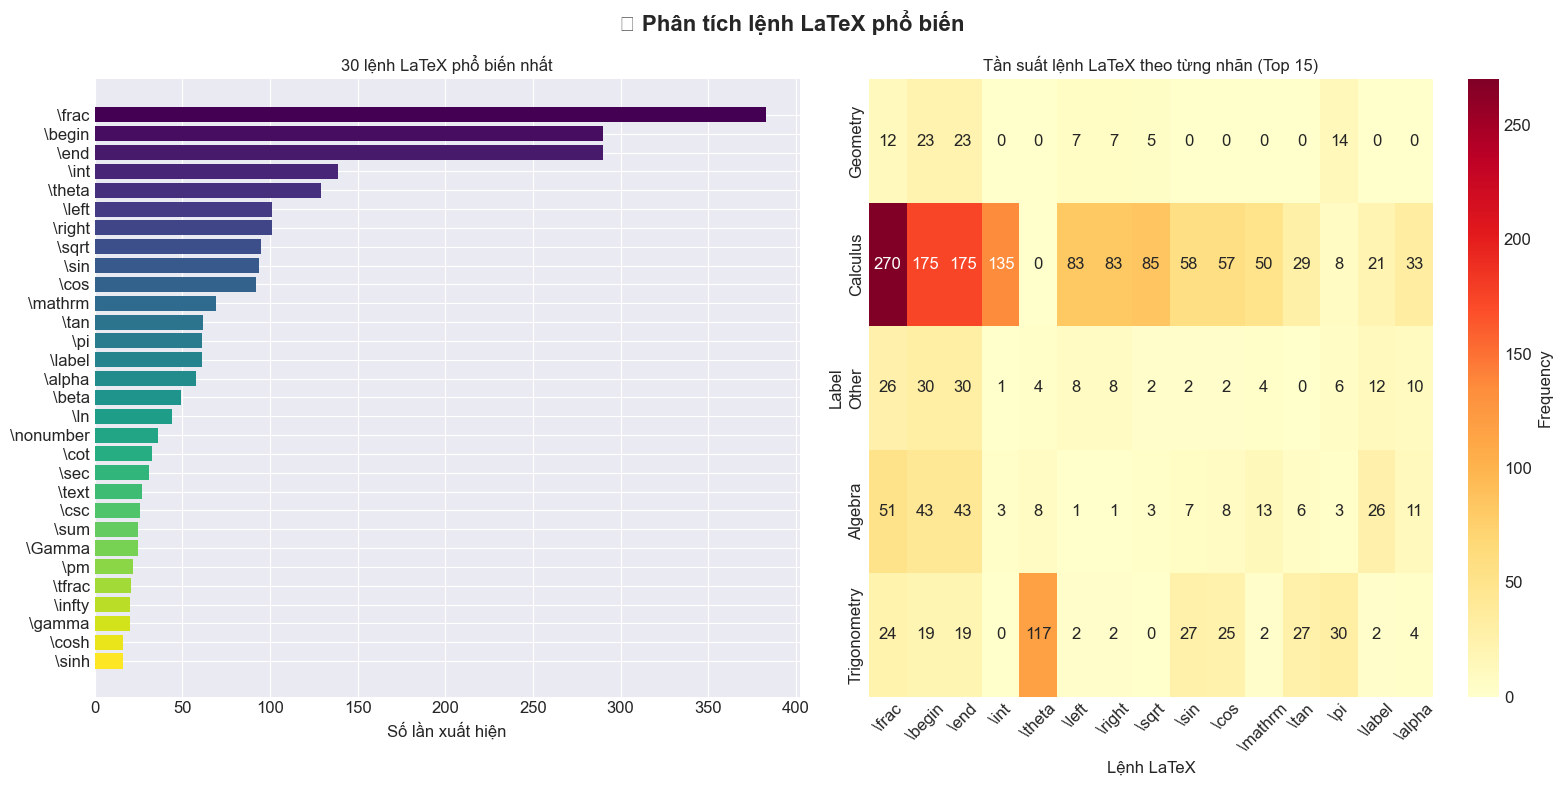

In [27]:
# === VISUALIZATION 4: Phân tích từ khóa và lệnh LaTeX ===
latex_commands = re.findall(r'\\[a-zA-Z]+', ' '.join(df['latex'].tolist()))
command_counts = Counter(latex_commands).most_common(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('🔤 Phân tích lệnh LaTeX phổ biến', fontsize=16, fontweight='bold')

# Top 30 lệnh
commands_df = pd.DataFrame(command_counts, columns=['Command', 'Count'])
commands_df = commands_df.head(30)

colors_cmd = plt.cm.viridis(np.linspace(0, 1, len(commands_df)))
axes[0].barh(commands_df['Command'], commands_df['Count'], color=colors_cmd)
axes[0].set_title('30 lệnh LaTeX phổ biến nhất', fontsize=12)
axes[0].set_xlabel('Số lần xuất hiện')
axes[0].invert_yaxis()

# SỬA LẠI: Tạo heatmap với dữ liệu số thay vì chuỗi
labels_list = df['label'].unique()
label_commands = {}

# Thu thập tần suất của các lệnh cho từng nhãn
for label in labels_list:
    label_text = ' '.join(df[df['label'] == label]['latex'].tolist())
    label_commands[label] = Counter(re.findall(r'\\[a-zA-Z]+', label_text))

# Lấy top 15 lệnh phổ biến nhất để hiển thị
all_commands_counter = Counter()
for label in labels_list:
    all_commands_counter.update(label_commands[label])
top_commands = [cmd for cmd, _ in all_commands_counter.most_common(15)]

# Tạo ma trận số liệu cho heatmap
command_matrix = []
for label in labels_list:
    row = []
    for cmd in top_commands:
        count = label_commands[label].get(cmd, 0)
        row.append(count)
    command_matrix.append(row)

# Chuyển thành DataFrame với dữ liệu số
command_df = pd.DataFrame(command_matrix, index=labels_list, columns=top_commands)

# Vẽ heatmap
sns.heatmap(command_df, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Frequency'})
axes[1].set_title('Tần suất lệnh LaTeX theo từng nhãn (Top 15)', fontsize=12)
axes[1].set_xlabel('Lệnh LaTeX')
axes[1].set_ylabel('Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

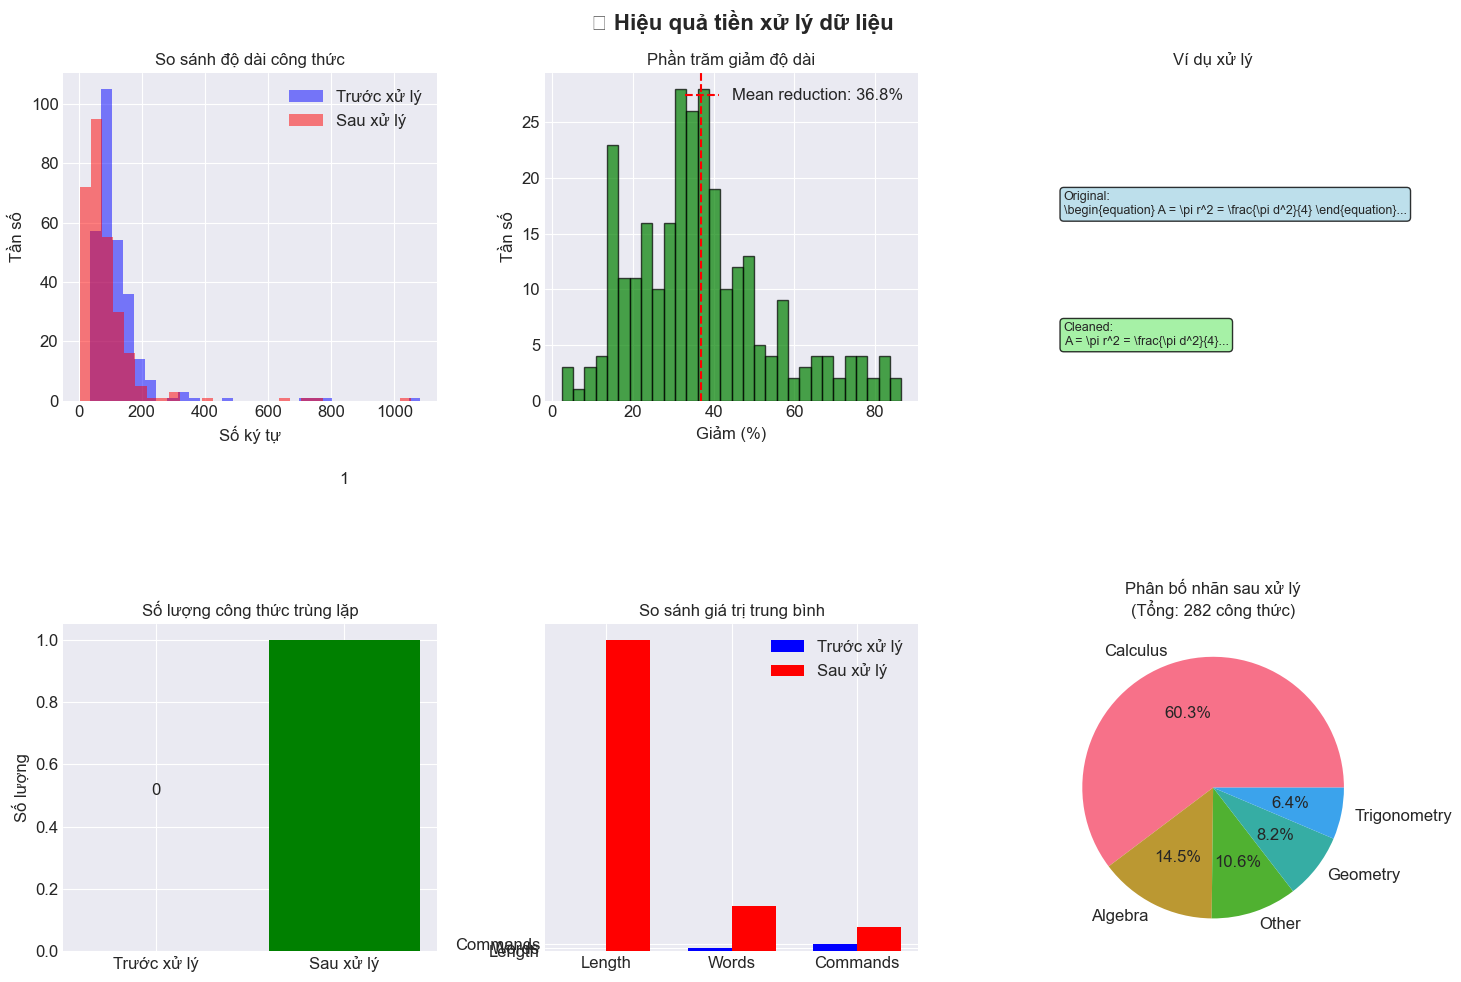


✅ Đã xóa 1 công thức trùng lặp
✅ Tổng số công thức sau xử lý: 282


In [22]:
# Hàm tiền xử lý LaTeX
def preprocess_latex(latex_str):
    """
    Tiền xử lý chuỗi LaTeX:
    - Loại bỏ các môi trường equation, align, etc.
    - Loại bỏ label
    - Giữ lại cấu trúc toán học
    """
    # Loại bỏ các nhãn \label{...}
    latex_str = re.sub(r'\\label\{[^}]*\}', '', latex_str)
    
    # Loại bỏ các môi trường begin/end
    latex_str = re.sub(r'\\begin\{[^}]*\}', '', latex_str)
    latex_str = re.sub(r'\\end\{[^}]*\}', '', latex_str)
    
    # Loại bỏ khoảng trắng thừa
    latex_str = re.sub(r'\s+', ' ', latex_str).strip()
    
    return latex_str

# Áp dụng tiền xử lý
df['cleaned_latex'] = df['latex'].apply(preprocess_latex)

# === VISUALIZATION 5: So sánh trước và sau tiền xử lý ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('🔄 Hiệu quả tiền xử lý dữ liệu', fontsize=16, fontweight='bold')

# Độ dài trước và sau
before_len = df['latex'].apply(len)
after_len = df['cleaned_latex'].apply(len)

axes[0, 0].hist(before_len, bins=30, alpha=0.5, label='Trước xử lý', color='blue')
axes[0, 0].hist(after_len, bins=30, alpha=0.5, label='Sau xử lý', color='red')
axes[0, 0].set_title('So sánh độ dài công thức', fontsize=12)
axes[0, 0].set_xlabel('Số ký tự')
axes[0, 0].set_ylabel('Tần số')
axes[0, 0].legend()

# Giảm độ dài
length_reduction = (before_len - after_len) / before_len * 100
axes[0, 1].hist(length_reduction, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(length_reduction.mean(), color='red', linestyle='--', 
                   label=f'Mean reduction: {length_reduction.mean():.1f}%')
axes[0, 1].set_title('Phần trăm giảm độ dài', fontsize=12)
axes[0, 1].set_xlabel('Giảm (%)')
axes[0, 1].set_ylabel('Tần số')
axes[0, 1].legend()

# Sample comparison
sample_idx = 0
original = df.iloc[sample_idx]['latex']
cleaned = df.iloc[sample_idx]['cleaned_latex']

axes[0, 2].text(0.1, 0.6, f'Original:\n{original[:150]}...', 
                ha='left', va='center', fontsize=9, transform=axes[0, 2].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
axes[0, 2].text(0.1, 0.2, f'Cleaned:\n{cleaned[:150]}...', 
                ha='left', va='center', fontsize=9, transform=axes[0, 2].transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))
axes[0, 2].set_title('Ví dụ xử lý', fontsize=12)
axes[0, 2].axis('off')

# Loại bỏ trùng lặp
duplicates_before = df.duplicated(subset=['latex']).sum()
df_no_dup = df.drop_duplicates(subset=['cleaned_latex', 'label'])
duplicates_after = len(df) - len(df_no_dup)

axes[1, 0].bar(['Trước xử lý', 'Sau xử lý'], [duplicates_before, duplicates_after], 
               color=['red', 'green'])
axes[1, 0].set_title('Số lượng công thức trùng lặp', fontsize=12)
axes[1, 0].set_ylabel('Số lượng')
for i, v in enumerate([duplicates_before, duplicates_after]):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center')

# Đặc trưng mới sau xử lý
df['cleaned_len'] = df['cleaned_latex'].apply(len)
df['cleaned_words'] = df['cleaned_latex'].apply(lambda x: len(x.split()))
df['cleaned_commands'] = df['cleaned_latex'].apply(lambda x: len(re.findall(r'\\[a-zA-Z]+', x)))

metrics_before = ['Length', 'Words', 'Commands']
metrics_after = [df['latex_length'].mean(), df['latex_words'].mean(), df['latex_commands'].mean()]
metrics_cleaned = [df['cleaned_len'].mean(), df['cleaned_words'].mean(), df['cleaned_commands'].mean()]

x = np.arange(len(metrics_before))
width = 0.35
axes[1, 1].bar(x - width/2, metrics_before, width, label='Trước xử lý', color='blue')
axes[1, 1].bar(x + width/2, metrics_cleaned, width, label='Sau xử lý', color='red')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_before)
axes[1, 1].set_title('So sánh giá trị trung bình', fontsize=12)
axes[1, 1].legend()

# Phân bố nhãn sau xử lý
df = df_no_dup
label_counts_after = df['label'].value_counts()

axes[1, 2].pie(label_counts_after.values, labels=label_counts_after.index, autopct='%1.1f%%')
axes[1, 2].set_title(f'Phân bố nhãn sau xử lý\n(Tổng: {len(df)} công thức)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n✅ Đã xóa {duplicates_after} công thức trùng lặp")
print(f"✅ Tổng số công thức sau xử lý: {len(df)}")

📊 Số lượng mẫu hiện tại: min=18, max=170
🎯 Số lượng mẫu mục tiêu (downsampling): 18


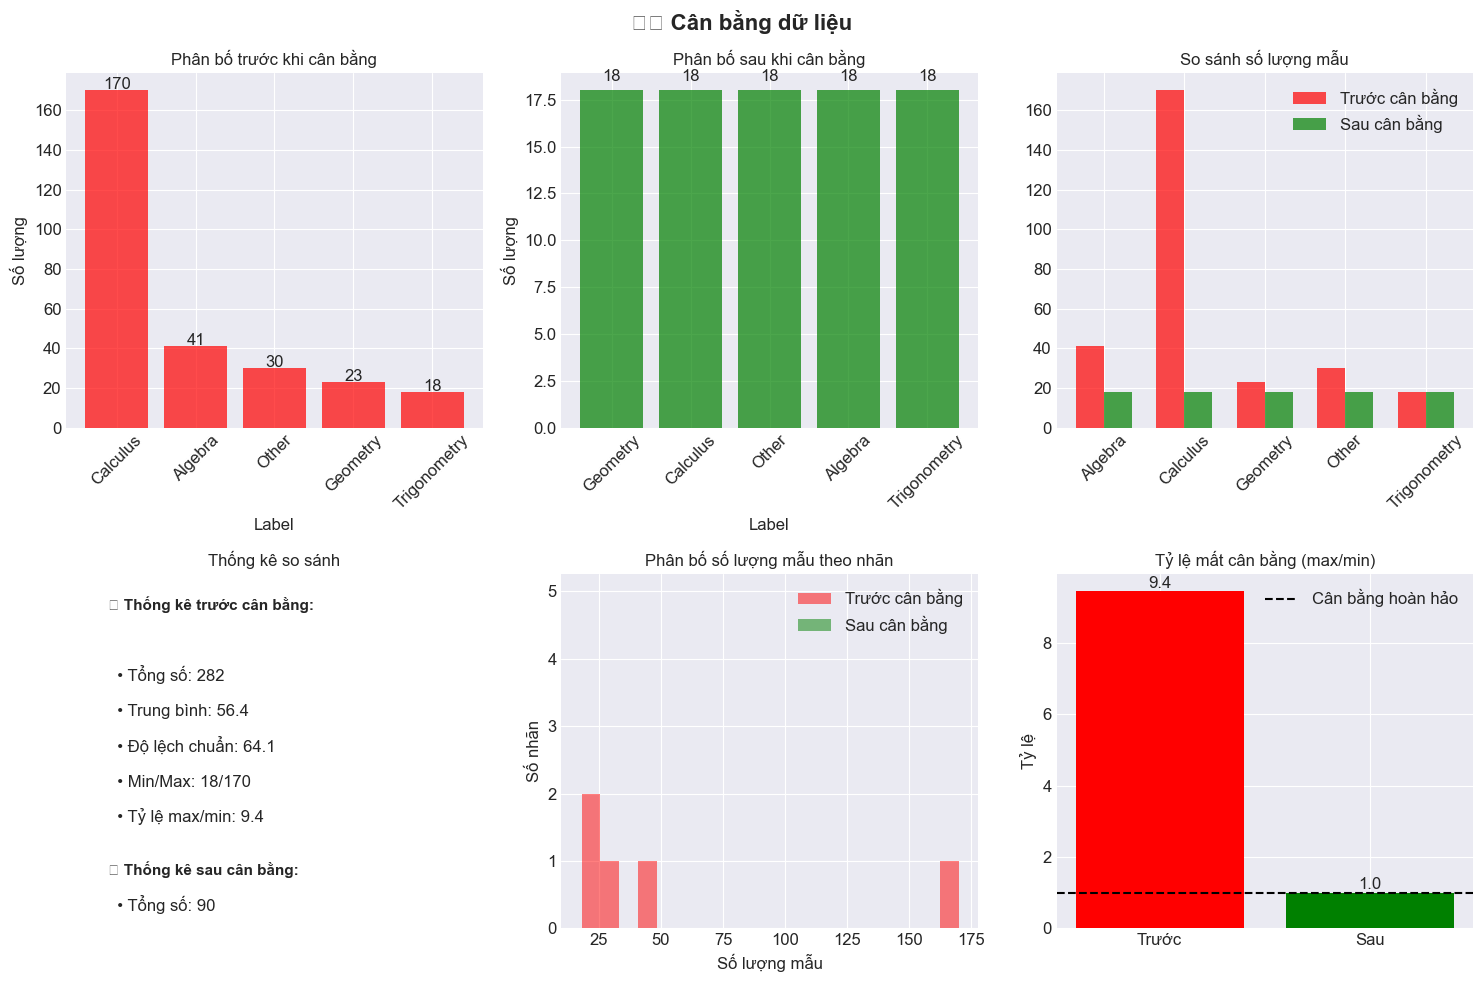


✅ Đã cân bằng dữ liệu thành công!
   - Số lượng trước: 282
   - Số lượng sau: 90
   - Giảm: 192 mẫu (68.1%)


In [23]:
# === VISUALIZATION 6: Cân bằng dữ liệu ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('⚖️ Cân bằng dữ liệu', fontsize=16, fontweight='bold')

# Phân bố trước khi cân bằng
label_counts_before = df['label'].value_counts()
axes[0, 0].bar(label_counts_before.index, label_counts_before.values, color='red', alpha=0.7)
axes[0, 0].set_title('Phân bố trước khi cân bằng', fontsize=12)
axes[0, 0].set_xlabel('Label')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(label_counts_before.items()):
    axes[0, 0].text(i, count + 0.5, str(count), ha='center')

# Tính toán số lượng mỗi nhãn sau cân bằng
max_samples = label_counts_before.max()
min_samples = label_counts_before.min()
target_samples = min_samples  # Downsampling

print(f"📊 Số lượng mẫu hiện tại: min={min_samples}, max={max_samples}")
print(f"🎯 Số lượng mẫu mục tiêu (downsampling): {target_samples}")

# Thực hiện downsampling
balanced_dfs = []
for label in df['label'].unique():
    class_df = df[df['label'] == label]
    if len(class_df) > target_samples:
        class_df = resample(class_df, 
                            replace=False, 
                            n_samples=target_samples,
                            random_state=42)
    balanced_dfs.append(class_df)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)

# Phân bố sau khi cân bằng
label_counts_after = df_balanced['label'].value_counts()
axes[0, 1].bar(label_counts_after.index, label_counts_after.values, color='green', alpha=0.7)
axes[0, 1].set_title('Phân bố sau khi cân bằng', fontsize=12)
axes[0, 1].set_xlabel('Label')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(label_counts_after.items()):
    axes[0, 1].text(i, count + 0.5, str(count), ha='center')

# So sánh trước và sau
comparison = pd.DataFrame({
    'Before': label_counts_before,
    'After': label_counts_after
}).fillna(0)

x = np.arange(len(comparison))
width = 0.35
axes[0, 2].bar(x - width/2, comparison['Before'], width, label='Trước cân bằng', color='red', alpha=0.7)
axes[0, 2].bar(x + width/2, comparison['After'], width, label='Sau cân bằng', color='green', alpha=0.7)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(comparison.index, rotation=45)
axes[0, 2].set_title('So sánh số lượng mẫu', fontsize=12)
axes[0, 2].legend()

# Thông tin thống kê
axes[1, 0].text(0.1, 0.9, f"📈 Thống kê trước cân bằng:", 
                fontsize=11, fontweight='bold', transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.7, f"  • Tổng số: {len(df)}", transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.6, f"  • Trung bình: {label_counts_before.mean():.1f}", transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.5, f"  • Độ lệch chuẩn: {label_counts_before.std():.1f}", transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.4, f"  • Min/Max: {min_samples}/{max_samples}", transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.3, f"  • Tỷ lệ max/min: {max_samples/min_samples:.1f}", transform=axes[1, 0].transAxes)

axes[1, 0].text(0.1, 0.15, f"📊 Thống kê sau cân bằng:", 
                fontsize=11, fontweight='bold', transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.05, f"  • Tổng số: {len(df_balanced)}", transform=axes[1, 0].transAxes)
axes[1, 0].set_title('Thống kê so sánh', fontsize=12)
axes[1, 0].axis('off')

# Histogram so sánh phân bố
axes[1, 1].hist(label_counts_before.values, bins=20, alpha=0.5, label='Trước cân bằng', color='red')
axes[1, 1].hist(label_counts_after.values, bins=20, alpha=0.5, label='Sau cân bằng', color='green')
axes[1, 1].set_title('Phân bố số lượng mẫu theo nhãn', fontsize=12)
axes[1, 1].set_xlabel('Số lượng mẫu')
axes[1, 1].set_ylabel('Số nhãn')
axes[1, 1].legend()

# Đánh giá cân bằng
imbalance_ratio_before = max_samples / min_samples
imbalance_ratio_after = label_counts_after.max() / label_counts_after.min()

axes[1, 2].bar(['Trước', 'Sau'], [imbalance_ratio_before, imbalance_ratio_after], 
               color=['red', 'green'])
axes[1, 2].axhline(y=1, color='black', linestyle='--', label='Cân bằng hoàn hảo')
axes[1, 2].set_title('Tỷ lệ mất cân bằng (max/min)', fontsize=12)
axes[1, 2].set_ylabel('Tỷ lệ')
axes[1, 2].legend()
for i, v in enumerate([imbalance_ratio_before, imbalance_ratio_after]):
    axes[1, 2].text(i, v + 0.1, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

print(f"\n✅ Đã cân bằng dữ liệu thành công!")
print(f"   - Số lượng trước: {len(df)}")
print(f"   - Số lượng sau: {len(df_balanced)}")
print(f"   - Giảm: {len(df) - len(df_balanced)} mẫu ({(1 - len(df_balanced)/len(df))*100:.1f}%)")

📋 Ánh xạ nhãn:
   Algebra              -> 0
   Calculus             -> 1
   Geometry             -> 2
   Other                -> 3
   Trigonometry         -> 4


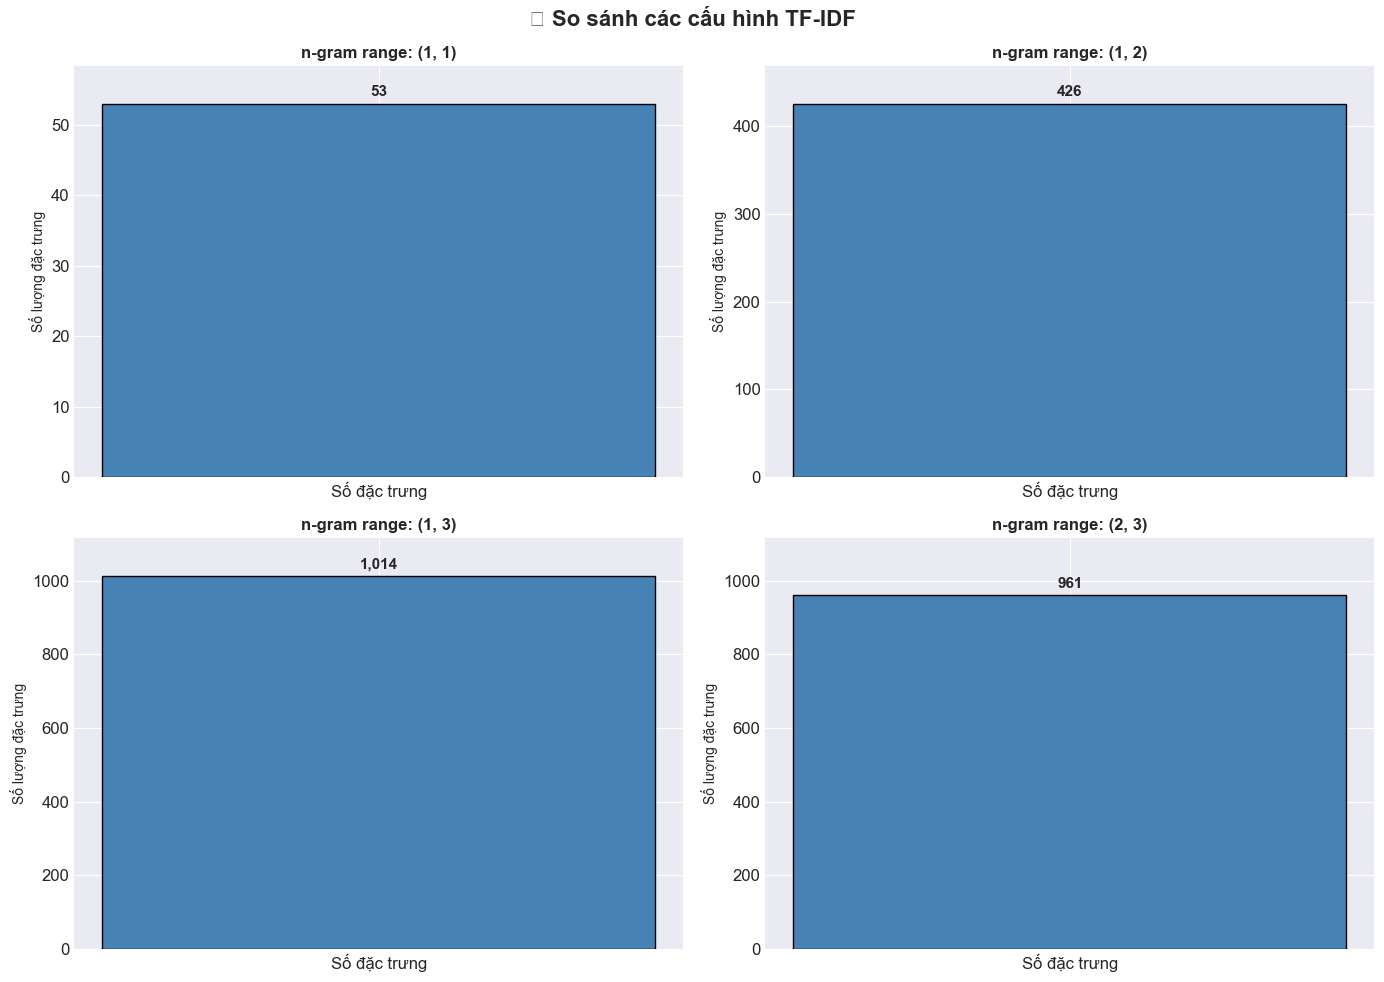


📊 So sánh các cấu hình n-gram:
   n-gram (1, 1): 53 đặc trưng
   n-gram (1, 2): 426 đặc trưng
   n-gram (1, 3): 1,014 đặc trưng
   n-gram (2, 3): 961 đặc trưng

✅ Đã trích xuất đặc trưng TF-IDF:
   - Số lượng mẫu: 90
   - Số lượng đặc trưng: 1,014
   - Độ thưa: 9.0708%
   - Số lượng phần tử khác 0: 8,278


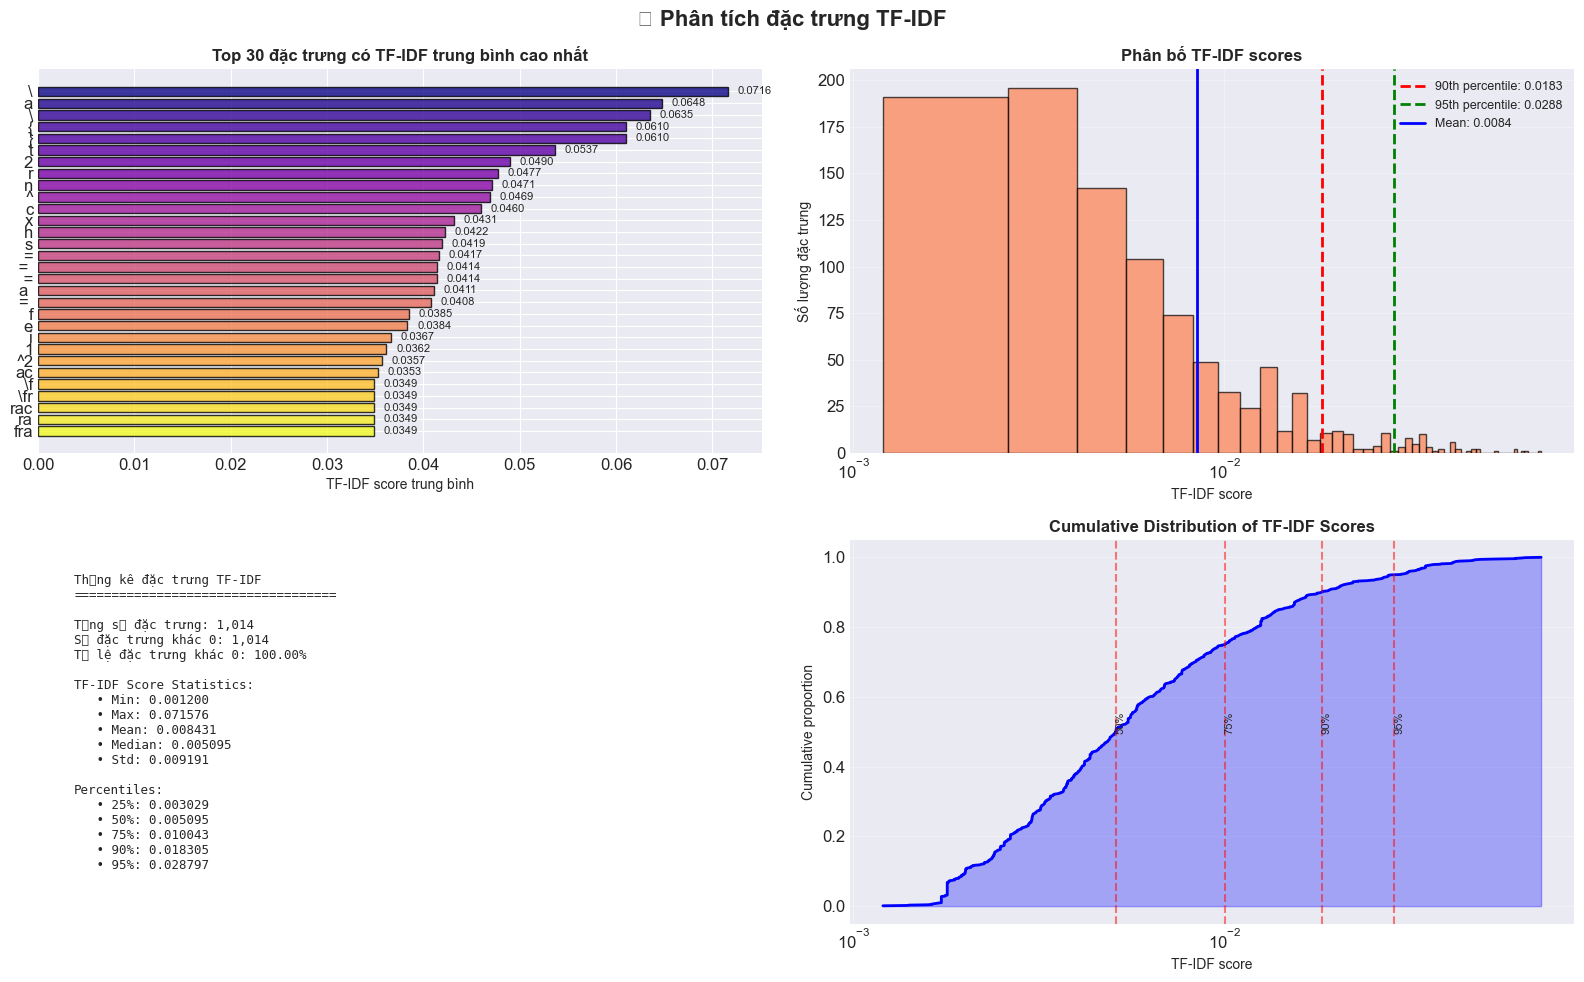


🏆 Top 10 đặc trưng quan trọng nhất:
Rank   Đặc trưng            TF-IDF Score   
------------------------------------------------------------
1      \                    0.071576
2      a                    0.064773
3       \                   0.063486
4      {                    0.061012
5      }                    0.061012
6      t                    0.053662
7      2                    0.048989
8      r                    0.047721
9      n                    0.047085
10     ^                    0.046894

📊 Phân tích đặc trưng đại diện cho từng nhãn:

   Algebra:
      • }
      • {
      • _
      • _{
      • n

   Calculus:
      • x
      • \
      • }
      • {
      •  \

   Geometry:
      •  a 
      •  a
      •  =
      •  = 
      • pi

   Other:
      • \
      •  \
      • x
      • _
      • s

   Trigonometry:
      • \t
      • ta
      • het
      • \th
      • the


In [29]:
# === VISUALIZATION 7: Trích xuất đặc trưng TF-IDF ===
# Mã hóa nhãn
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_balanced['label'])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("📋 Ánh xạ nhãn:")
print("=" * 40)
for label, code in label_mapping.items():
    print(f"   {label:20s} -> {code}")

# Trích xuất đặc trưng với các ngram khác nhau
ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 3)]
feature_counts = []
feature_names_list = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🔍 So sánh các cấu hình TF-IDF', fontsize=16, fontweight='bold')

# Lưu kết quả để so sánh
ngram_results = []

for idx, ngram in enumerate(ngram_ranges):
    row, col = idx // 2, idx % 2
    vectorizer = TfidfVectorizer(
        max_features=3000,
        ngram_range=ngram,
        min_df=2,
        max_df=0.95,
        analyzer='char_wb'
    )
    X_temp = vectorizer.fit_transform(df_balanced['cleaned_latex'])
    feature_counts.append(X_temp.shape[1])
    feature_names_list.append(vectorizer.get_feature_names_out())
    ngram_results.append({
        'ngram': ngram,
        'n_features': X_temp.shape[1],
        'vectorizer': vectorizer
    })
    
    # Vẽ bar chart
    axes[row, col].bar(['Số đặc trưng'], [X_temp.shape[1]], color='steelblue', edgecolor='black')
    axes[row, col].set_title(f'n-gram range: {ngram}', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Số lượng đặc trưng', fontsize=10)
    axes[row, col].set_ylim(0, max(feature_counts) * 1.1)
    axes[row, col].text(0, X_temp.shape[1] + max(feature_counts)*0.02, 
                        f'{X_temp.shape[1]:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Hiển thị so sánh các cấu hình
print("\n📊 So sánh các cấu hình n-gram:")
print("=" * 50)
for result in ngram_results:
    print(f"   n-gram {result['ngram']}: {result['n_features']:,} đặc trưng")

# Chọn cấu hình tốt nhất (dựa trên số lượng đặc trưng cân bằng)
best_ngram = (1, 3)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=best_ngram,
    min_df=2,
    max_df=0.95,
    analyzer='char_wb',
    sublinear_tf=True  # Thêm sublinear scaling để cải thiện
)

X = tfidf_vectorizer.fit_transform(df_balanced['cleaned_latex'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\n✅ Đã trích xuất đặc trưng TF-IDF:")
print(f"   - Số lượng mẫu: {X.shape[0]:,}")
print(f"   - Số lượng đặc trưng: {X.shape[1]:,}")
print(f"   - Độ thưa: {X.nnz / (X.shape[0] * X.shape[1]) * 100:.4f}%")
print(f"   - Số lượng phần tử khác 0: {X.nnz:,}")

# === VISUALIZATION 8: Top đặc trưng quan trọng ===
# Tính TF-IDF trung bình cho từng đặc trưng
tfidf_means = np.array(X.mean(axis=0)).flatten()
# Lọc các đặc trưng có TF-IDF > 0
non_zero_indices = tfidf_means > 0
tfidf_means_nonzero = tfidf_means[non_zero_indices]
feature_names_nonzero = feature_names[non_zero_indices]

# Lấy top 30 đặc trưng
top_n = min(30, len(tfidf_means_nonzero))
top_indices = np.argsort(tfidf_means_nonzero)[-top_n:][::-1]
top_features = feature_names_nonzero[top_indices]
top_scores = tfidf_means_nonzero[top_indices]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('🏆 Phân tích đặc trưng TF-IDF', fontsize=16, fontweight='bold')

# Top 30 đặc trưng
colors_top = plt.cm.plasma(np.linspace(0, 1, len(top_features)))
bars = axes[0, 0].barh(top_features, top_scores, color=colors_top, edgecolor='black', alpha=0.8)
axes[0, 0].set_title(f'Top {top_n} đặc trưng có TF-IDF trung bình cao nhất', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('TF-IDF score trung bình', fontsize=10)
axes[0, 0].invert_yaxis()
# Thêm giá trị số
for i, (bar, score) in enumerate(zip(bars, top_scores)):
    axes[0, 0].text(score + 0.001, bar.get_y() + bar.get_height()/2, 
                    f'{score:.4f}', va='center', fontsize=8)

# Phân bố TF-IDF scores (log scale)
nonzero_scores = tfidf_means[tfidf_means > 0]
axes[0, 1].hist(nonzero_scores, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(np.percentile(nonzero_scores, 90), color='red', 
                   linestyle='--', linewidth=2, label=f'90th percentile: {np.percentile(nonzero_scores, 90):.4f}')
axes[0, 1].axvline(np.percentile(nonzero_scores, 95), color='green', 
                   linestyle='--', linewidth=2, label=f'95th percentile: {np.percentile(nonzero_scores, 95):.4f}')
axes[0, 1].axvline(np.mean(nonzero_scores), color='blue', 
                   linestyle='-', linewidth=2, label=f'Mean: {np.mean(nonzero_scores):.4f}')
axes[0, 1].set_title('Phân bố TF-IDF scores', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('TF-IDF score', fontsize=10)
axes[0, 1].set_ylabel('Số lượng đặc trưng', fontsize=10)
axes[0, 1].set_xscale('log')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Thống kê đặc trưng
stats_text = f"""
Thống kê đặc trưng TF-IDF
{'='*35}

Tổng số đặc trưng: {len(feature_names):,}
Số đặc trưng khác 0: {len(nonzero_scores):,}
Tỷ lệ đặc trưng khác 0: {len(nonzero_scores)/len(feature_names)*100:.2f}%

TF-IDF Score Statistics:
   • Min: {np.min(nonzero_scores):.6f}
   • Max: {np.max(nonzero_scores):.6f}
   • Mean: {np.mean(nonzero_scores):.6f}
   • Median: {np.median(nonzero_scores):.6f}
   • Std: {np.std(nonzero_scores):.6f}

Percentiles:
   • 25%: {np.percentile(nonzero_scores, 25):.6f}
   • 50%: {np.percentile(nonzero_scores, 50):.6f}
   • 75%: {np.percentile(nonzero_scores, 75):.6f}
   • 90%: {np.percentile(nonzero_scores, 90):.6f}
   • 95%: {np.percentile(nonzero_scores, 95):.6f}
"""
axes[1, 0].text(0.05, 0.95, stats_text, transform=axes[1, 0].transAxes, 
                fontsize=9, fontfamily='monospace', verticalalignment='top')
axes[1, 0].axis('off')

# Cumulative distribution of TF-IDF scores
sorted_scores = np.sort(nonzero_scores)
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)

axes[1, 1].plot(sorted_scores, cumulative, 'b-', linewidth=2)
axes[1, 1].fill_between(sorted_scores, cumulative, alpha=0.3, color='blue')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('TF-IDF score', fontsize=10)
axes[1, 1].set_ylabel('Cumulative proportion', fontsize=10)
axes[1, 1].set_title('Cumulative Distribution of TF-IDF Scores', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
# Thêm các đường percentile
for p in [50, 75, 90, 95]:
    val = np.percentile(nonzero_scores, p)
    axes[1, 1].axvline(val, color='red', linestyle='--', alpha=0.5)
    axes[1, 1].text(val, 0.5, f'{p}%', rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

# Hiển thị top 10 đặc trưng chi tiết
print("\n🏆 Top 10 đặc trưng quan trọng nhất:")
print("=" * 60)
print(f"{'Rank':<6} {'Đặc trưng':<20} {'TF-IDF Score':<15}")
print("-" * 60)
for i, (feature, score) in enumerate(zip(top_features[:10], top_scores[:10]), 1):
    # Giải mã đặc trưng (có thể là các n-gram ký tự)
    print(f"{i:<6} {feature:<20} {score:.6f}")

# Phân tích đặc trưng theo nhãn (tùy chọn)
print("\n📊 Phân tích đặc trưng đại diện cho từng nhãn:")
print("=" * 60)

# Tính TF-IDF trung bình theo từng nhãn
label_features = {}
for label in label_encoder.classes_:
    label_idx = label_encoder.transform([label])[0]
    label_mask = (y == label_idx)
    if label_mask.sum() > 0:
        label_tfidf = X[label_mask].mean(axis=0).A1
        top_label_indices = np.argsort(label_tfidf)[-5:][::-1]
        label_features[label] = feature_names[top_label_indices]

for label, features in label_features.items():
    print(f"\n   {label}:")
    for feat in features:
        print(f"      • {feat}")

⏳ Đang tính t-SNE (có thể mất vài phút)...


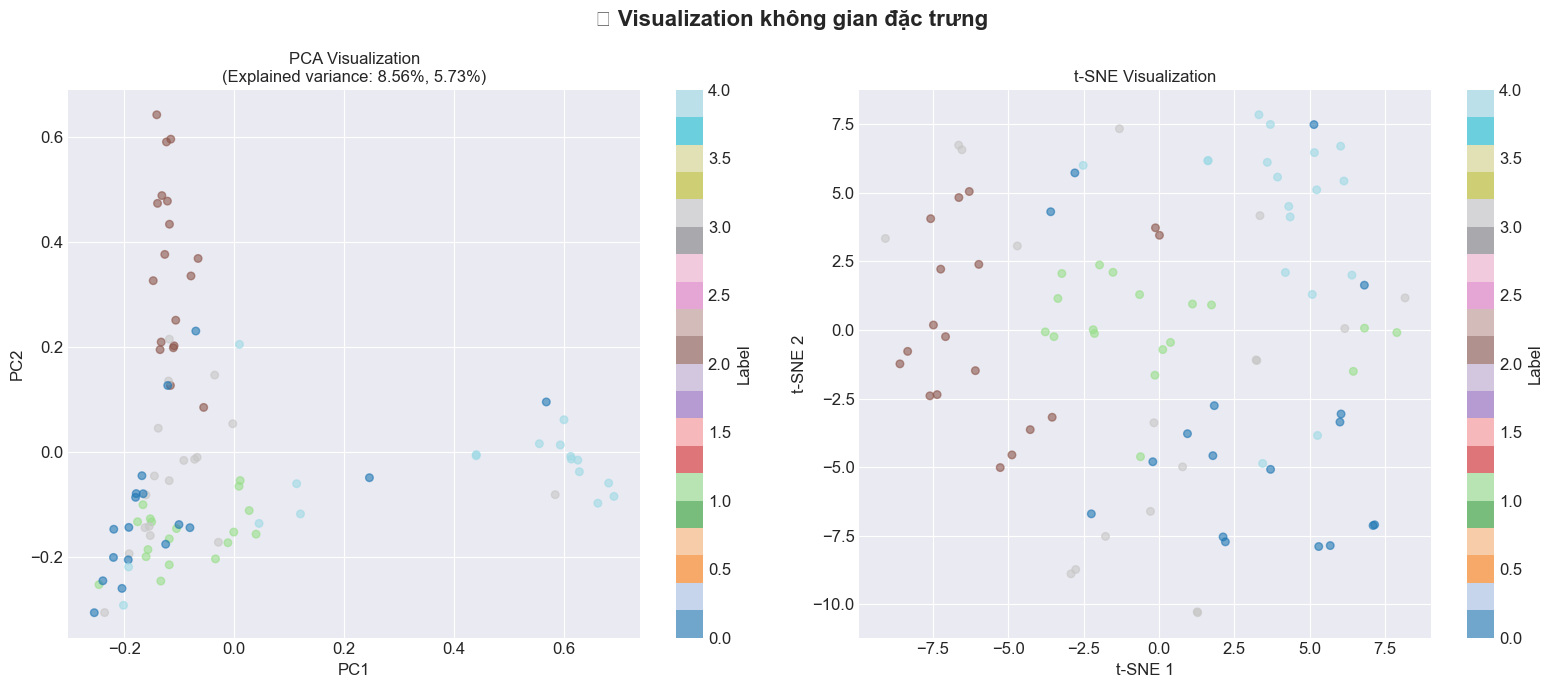


✅ PCA explained variance ratio: 8.56%, 5.73%


In [31]:
# === VISUALIZATION 9: PCA và t-SNE giảm chiều ===
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('📊 Visualization không gian đặc trưng', fontsize=16, fontweight='bold')

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())
explained_var = pca.explained_variance_ratio_

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab20', alpha=0.6, s=30)
axes[0].set_title(f'PCA Visualization\n(Explained variance: {explained_var[0]:.2%}, {explained_var[1]:.2%})', 
                  fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Label')

# t-SNE (lấy mẫu để giảm thời gian)
sample_size = min(1000, len(X.toarray()))
sample_idx = np.random.choice(len(X.toarray()), sample_size, replace=False)
X_sample = X.toarray()[sample_idx]
y_sample = y[sample_idx]

print("⏳ Đang tính t-SNE (có thể mất vài phút)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab20', alpha=0.6, s=30)
axes[1].set_title('t-SNE Visualization', fontsize=12)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Label')

plt.tight_layout()
plt.show()

print(f"\n✅ PCA explained variance ratio: {explained_var[0]:.2%}, {explained_var[1]:.2%}")

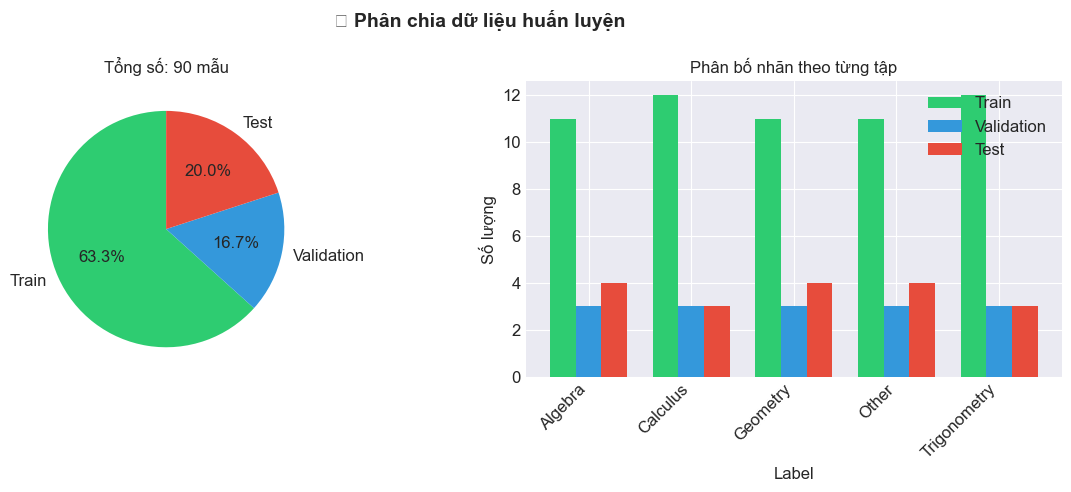


✅ Phân chia dữ liệu:
   - Train: 57 mẫu
   - Validation: 15 mẫu
   - Test: 18 mẫu

📊 Chi tiết phân bố nhãn:

Label                Train      Validation Test      
-------------------------------------------------------
Algebra              11         3          4         
Calculus             12         3          3         
Geometry             11         3          4         
Other                11         3          4         
Trigonometry         12         3          3         


In [33]:
# === VISUALIZATION 10: Chia dữ liệu ===
# Chia dữ liệu: train, validation, test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('📊 Phân chia dữ liệu huấn luyện', fontsize=14, fontweight='bold')

# Số lượng mẫu - SỬA LỖI: dùng shape[0] thay vì len()
sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels_parts = ['Train', 'Validation', 'Test']
colors_parts = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].pie(sizes, labels=labels_parts, autopct='%1.1f%%', colors=colors_parts, startangle=90)
axes[0].set_title(f'Tổng số: {X.shape[0]} mẫu', fontsize=12)

# Phân bố nhãn trong các tập
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

x = np.arange(len(train_counts))
width = 0.25

axes[1].bar(x - width, train_counts.values, width, label='Train', color='#2ecc71')
axes[1].bar(x, val_counts.values, width, label='Validation', color='#3498db')
axes[1].bar(x + width, test_counts.values, width, label='Test', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
axes[1].set_title('Phân bố nhãn theo từng tập', fontsize=12)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Số lượng')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Phân chia dữ liệu:")
print(f"   - Train: {X_train.shape[0]} mẫu")
print(f"   - Validation: {X_val.shape[0]} mẫu")
print(f"   - Test: {X_test.shape[0]} mẫu")
print(f"\n📊 Chi tiết phân bố nhãn:")
print(f"\n{'Label':<20} {'Train':<10} {'Validation':<10} {'Test':<10}")
print("-" * 55)
for i, label in enumerate(label_encoder.classes_):
    train_cnt = train_counts.get(i, 0)
    val_cnt = val_counts.get(i, 0)
    test_cnt = test_counts.get(i, 0)
    print(f"{label:<20} {train_cnt:<10} {val_cnt:<10} {test_cnt:<10}")

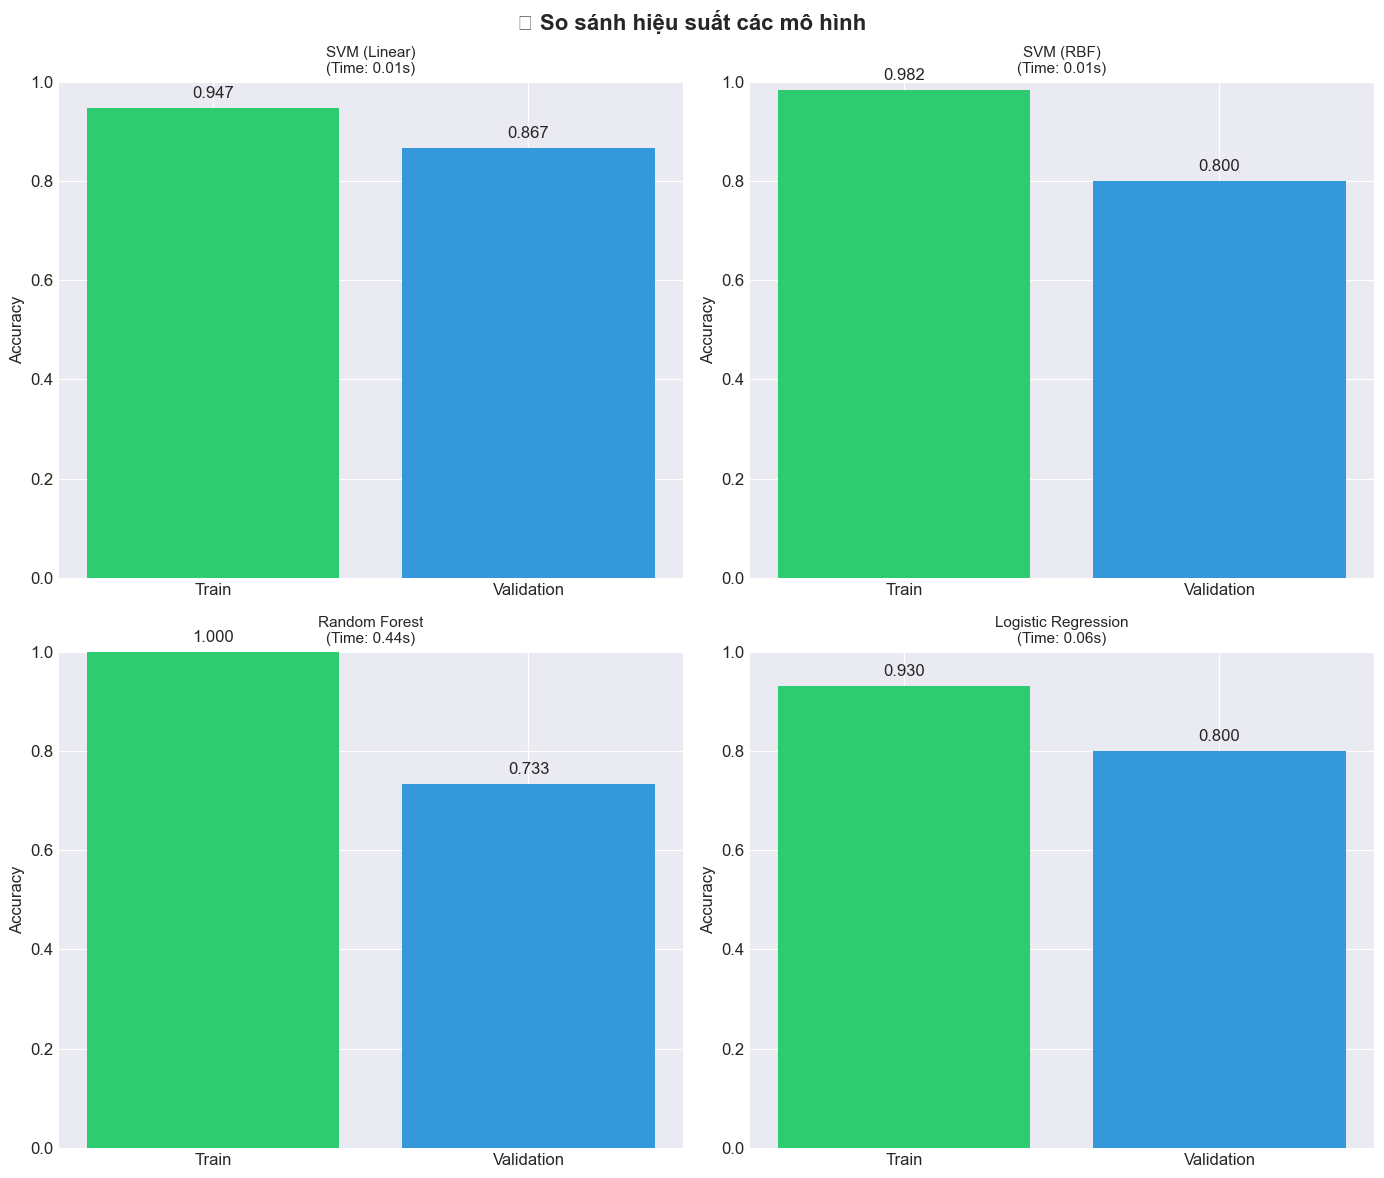

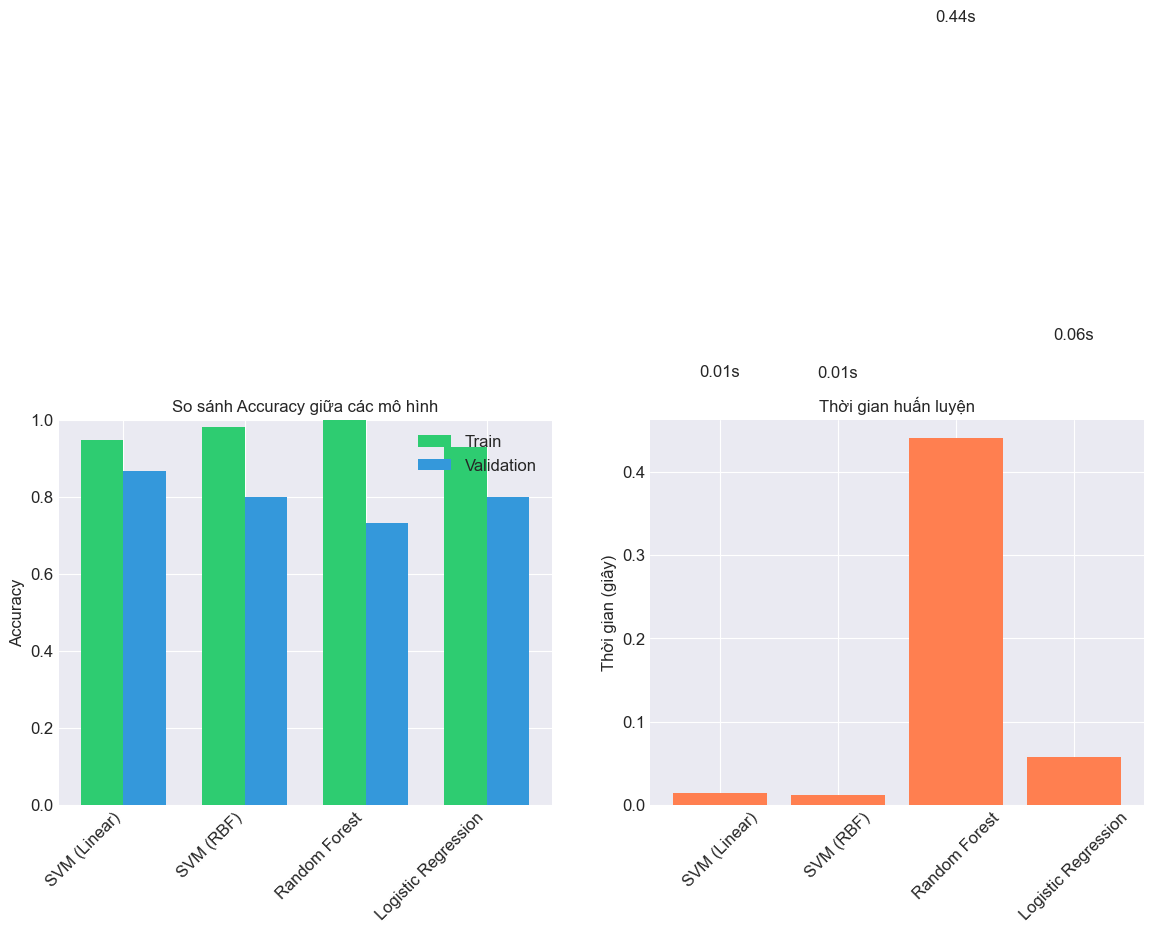


📊 Bảng so sánh kết quả:
              Model  Train Accuracy  Validation Accuracy  Training Time (s)
       SVM (Linear)        0.947368             0.866667           0.013998
          SVM (RBF)        0.982456             0.800000           0.012211
      Random Forest        1.000000             0.733333           0.440003
Logistic Regression        0.929825             0.800000           0.058134


In [34]:
# === VISUALIZATION 11: Huấn luyện và so sánh các mô hình ===
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, C=1.0),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, C=1.0, gamma='scale'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Huấn luyện và lưu kết quả
training_results = {}
validation_results = {}
training_times = {}

import time

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('🤖 So sánh hiệu suất các mô hình', fontsize=16, fontweight='bold')

for idx, (name, model) in enumerate(models.items()):
    row, col = idx // 2, idx % 2
    
    # Huấn luyện
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    training_times[name] = train_time
    
    # Dự đoán
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Đánh giá
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    training_results[name] = train_acc
    validation_results[name] = val_acc
    
    # Vẽ
    axes[row, col].bar(['Train', 'Validation'], [train_acc, val_acc], 
                       color=['#2ecc71', '#3498db'])
    axes[row, col].set_ylim(0, 1)
    axes[row, col].set_title(f'{name}\n(Time: {train_time:.2f}s)', fontsize=11)
    axes[row, col].set_ylabel('Accuracy')
    for i, v in enumerate([train_acc, val_acc]):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# So sánh tổng hợp
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models_list = list(training_results.keys())
train_accs = [training_results[m] for m in models_list]
val_accs = [validation_results[m] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Train', color='#2ecc71')
axes[0].bar(x + width/2, val_accs, width, label='Validation', color='#3498db')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('So sánh Accuracy giữa các mô hình', fontsize=12)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Training time comparison
axes[1].bar(models_list, [training_times[m] for m in models_list], color='coral')
axes[1].set_ylabel('Thời gian (giây)')
axes[1].set_title('Thời gian huấn luyện', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate([training_times[m] for m in models_list]):
    axes[1].text(i, v + 0.5, f'{v:.2f}s', ha='center')

plt.tight_layout()
plt.show()

# Bảng kết quả
results_comparison = pd.DataFrame({
    'Model': models_list,
    'Train Accuracy': train_accs,
    'Validation Accuracy': val_accs,
    'Training Time (s)': [training_times[m] for m in models_list]
})
print("\n📊 Bảng so sánh kết quả:")
print(results_comparison.to_string(index=False))

🔧 Đang tinh chỉnh hyperparameters cho SVM...


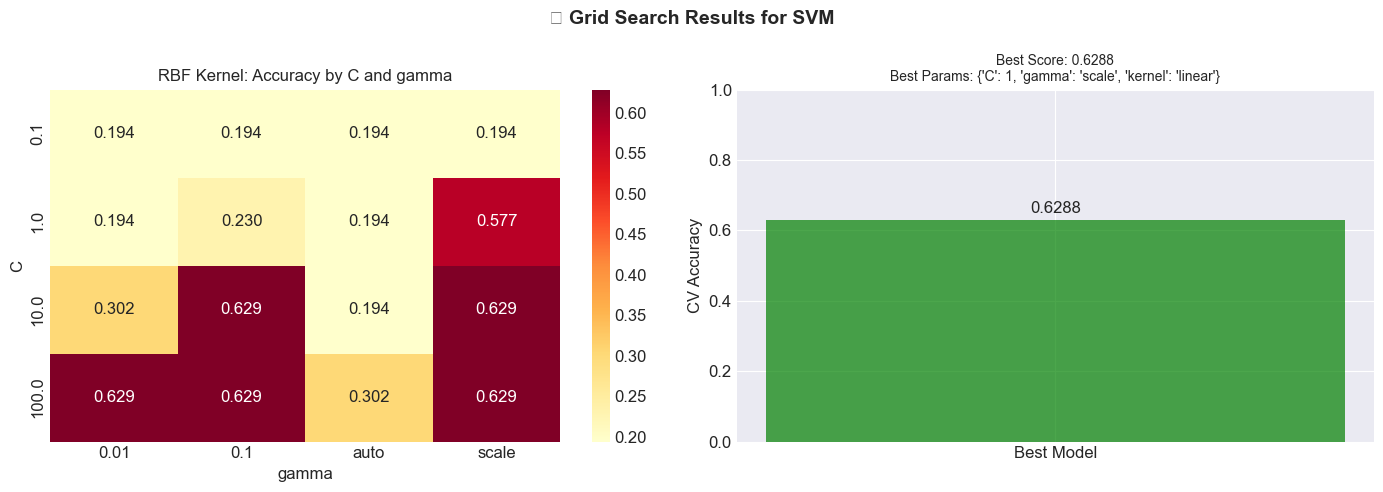


✅ Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
✅ Best CV score: 0.6288

📊 SVM sau tinh chỉnh:
   - Validation Accuracy: 0.8667
   - Test Accuracy: 0.6667


In [35]:
# === VISUALIZATION 12: Tinh chỉnh hyperparameters cho SVM ===
from sklearn.model_selection import GridSearchCV

print("🔧 Đang tinh chỉnh hyperparameters cho SVM...")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

svm = SVC(random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Visualization of grid search results
results_grid = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 Grid Search Results for SVM', fontsize=14, fontweight='bold')

# Heatmap for C vs gamma (RBF kernel)
rbf_results = results_grid[results_grid['param_kernel'] == 'rbf'].copy()
rbf_results['param_C'] = rbf_results['param_C'].astype(float)
rbf_results['param_gamma'] = rbf_results['param_gamma'].astype(str)

pivot_table = rbf_results.pivot_table(
    values='mean_test_score', 
    index='param_C', 
    columns='param_gamma'
)

sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('RBF Kernel: Accuracy by C and gamma', fontsize=12)
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('C')

# Best parameters and scores
linear_results = results_grid[results_grid['param_kernel'] == 'linear']
best_rbf_idx = rbf_results['mean_test_score'].idxmax()
best_linear_idx = linear_results['mean_test_score'].idxmax() if len(linear_results) > 0 else None

best_params = grid_search.best_params_
best_score = grid_search.best_score_

axes[1].bar(['Best Model'], [best_score], color='green', alpha=0.7)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title(f'Best Score: {best_score:.4f}\nBest Params: {best_params}', fontsize=10)
axes[1].text(0, best_score + 0.02, f'{best_score:.4f}', ha='center')

plt.tight_layout()
plt.show()

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV score: {grid_search.best_score_:.4f}")

# Mô hình SVM tốt nhất
best_svm = grid_search.best_estimator_

# Đánh giá trên validation và test
y_val_pred_svm = best_svm.predict(X_val)
y_test_pred_svm = best_svm.predict(X_test)

val_acc_svm = accuracy_score(y_val, y_val_pred_svm)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"\n📊 SVM sau tinh chỉnh:")
print(f"   - Validation Accuracy: {val_acc_svm:.4f}")
print(f"   - Test Accuracy: {test_acc_svm:.4f}")

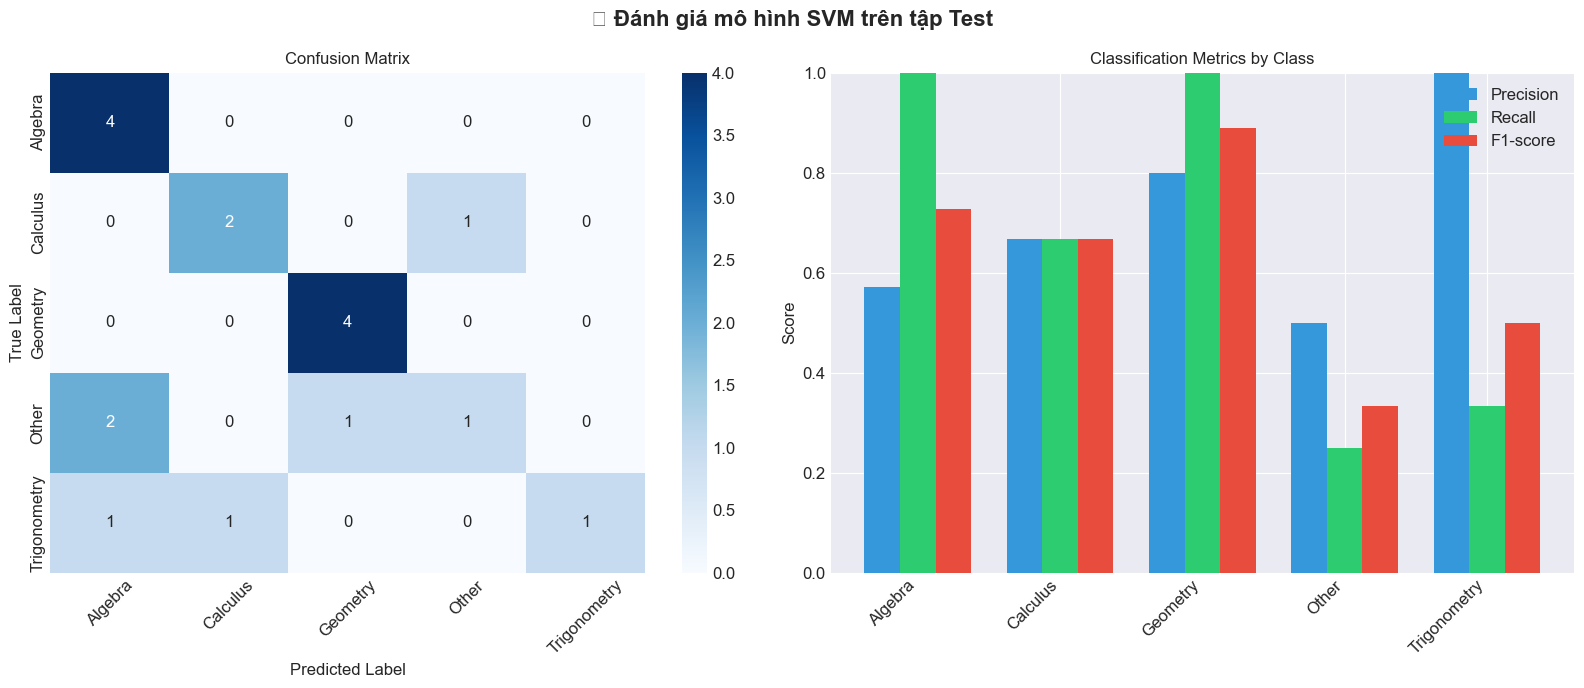


📋 Classification Report chi tiết:
              precision    recall  f1-score   support

     Algebra       0.57      1.00      0.73         4
    Calculus       0.67      0.67      0.67         3
    Geometry       0.80      1.00      0.89         4
       Other       0.50      0.25      0.33         4
Trigonometry       1.00      0.33      0.50         3

    accuracy                           0.67        18
   macro avg       0.71      0.65      0.62        18
weighted avg       0.69      0.67      0.63        18



In [36]:
# === VISUALIZATION 13: Confusion Matrix và Classification Report ===
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('📈 Đánh giá mô hình SVM trên tập Test', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[0].set_title('Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)

# Classification Report Visualization
report = classification_report(y_test, y_test_pred_svm, 
                                target_names=label_encoder.classes_, 
                                output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Chỉ lấy các lớp và metrics chính
metrics_df = report_df[['precision', 'recall', 'f1-score']].dropna()
metrics_df = metrics_df.iloc[:-3]  # Bỏ dòng avg

x = np.arange(len(metrics_df))
width = 0.25

axes[1].bar(x - width, metrics_df['precision'], width, label='Precision', color='#3498db')
axes[1].bar(x, metrics_df['recall'], width, label='Recall', color='#2ecc71')
axes[1].bar(x + width, metrics_df['f1-score'], width, label='F1-score', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_df.index, rotation=45, ha='right')
axes[1].set_ylim(0, 1)
axes[1].set_title('Classification Metrics by Class', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# In chi tiết classification report
print("\n📋 Classification Report chi tiết:")
print("=" * 60)
print(classification_report(y_test, y_test_pred_svm, target_names=label_encoder.classes_))

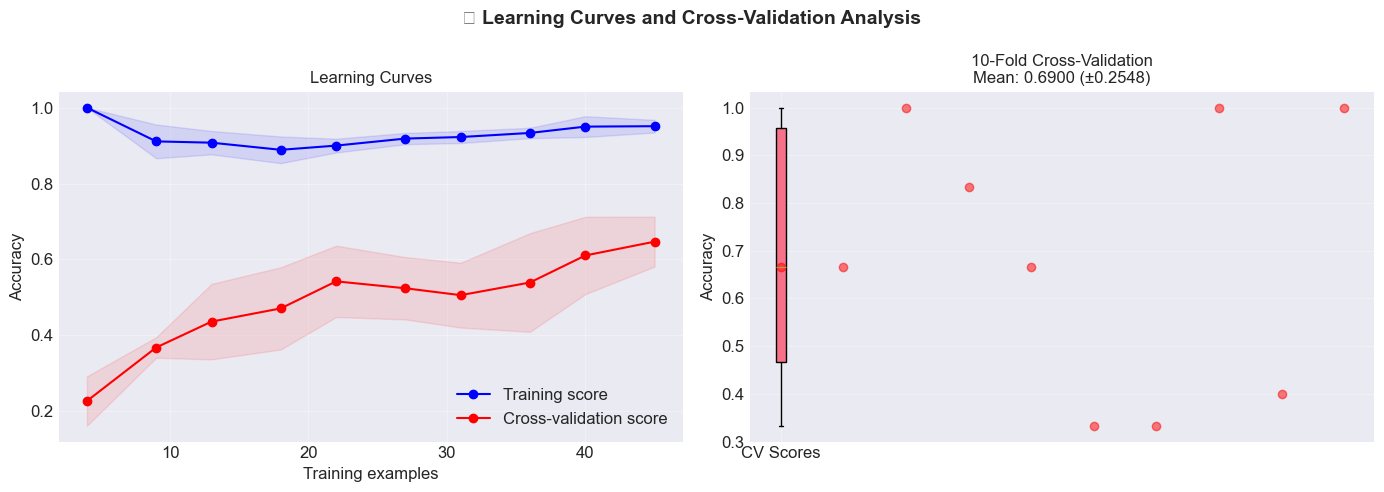


✅ Cross-validation results:
   - Mean accuracy: 0.6900
   - Std deviation: 0.2548
   - Min/Max: 0.3333 / 1.0000


In [37]:
# === VISUALIZATION 14: Learning Curves và Cross-Validation ===
from sklearn.model_selection import learning_curve, validation_curve

# Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    best_svm, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Learning Curves and Cross-Validation Analysis', fontsize=14, fontweight='bold')

# Learning curve
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                     alpha=0.1, color='red')
axes[0].plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
axes[0].plot(train_sizes, val_mean, 'o-', color='red', label='Cross-validation score')
axes[0].set_xlabel('Training examples')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Learning Curves', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cross-validation scores
cv_scores = cross_val_score(best_svm, X_train, y_train, cv=10, scoring='accuracy')

axes[1].boxplot(cv_scores, vert=True, patch_artist=True)
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'10-Fold Cross-Validation\nMean: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})', 
                  fontsize=12)
axes[1].set_xticklabels(['CV Scores'])
axes[1].grid(True, alpha=0.3)

# Thêm các điểm dữ liệu
for i, score in enumerate(cv_scores):
    axes[1].plot(i + 1, score, 'ro', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n✅ Cross-validation results:")
print(f"   - Mean accuracy: {cv_scores.mean():.4f}")
print(f"   - Std deviation: {cv_scores.std():.4f}")
print(f"   - Min/Max: {cv_scores.min():.4f} / {cv_scores.max():.4f}")

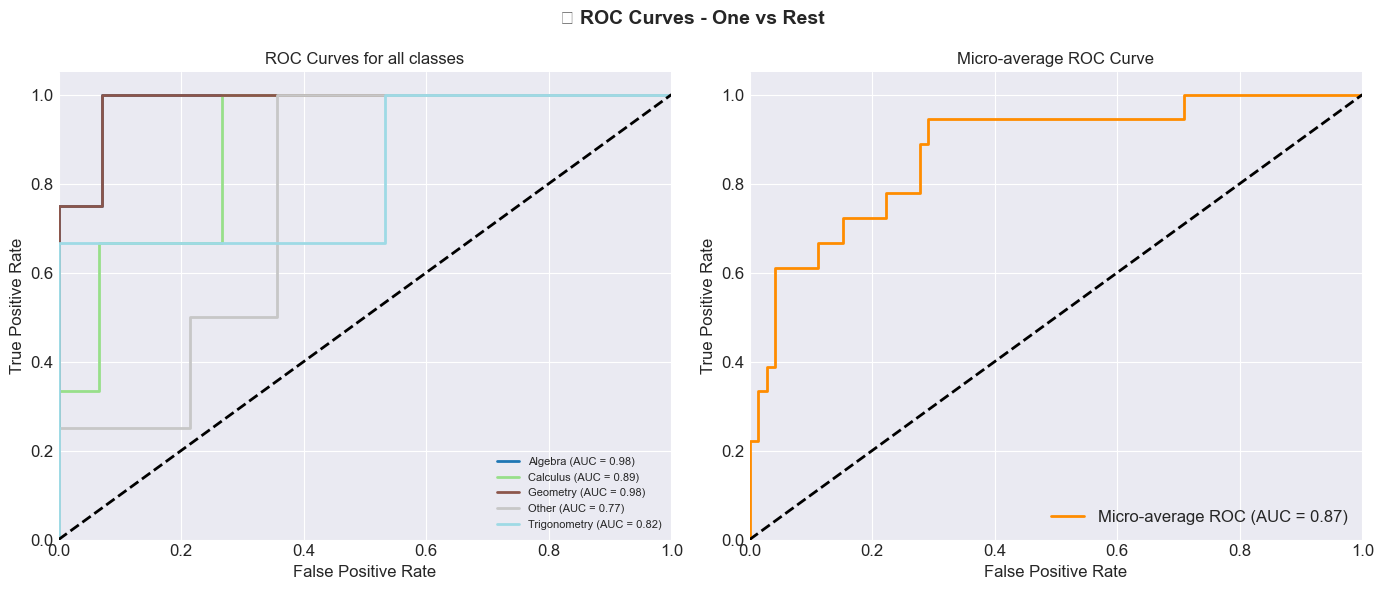


✅ AUC Scores:
   - Algebra: 0.9821
   - Calculus: 0.8889
   - Geometry: 0.9821
   - Other: 0.7679
   - Trigonometry: 0.8222
   - Micro-average: 0.8742


In [38]:
# === VISUALIZATION 15: ROC Curves (One-vs-Rest) ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Calibrate SVM for probability
calibrated_svm = CalibratedClassifierCV(best_svm, method='sigmoid', cv=3)
calibrated_svm.fit(X_train, y_train)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = len(label_encoder.classes_)

# Predict probabilities
y_score = calibrated_svm.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('🎯 ROC Curves - One vs Rest', fontsize=14, fontweight='bold')

# All classes
colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    axes[0].plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves for all classes', fontsize=12)
axes[0].legend(loc="lower right", fontsize=8)

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

axes[1].plot(fpr_micro, tpr_micro, color='darkorange', lw=2,
             label=f'Micro-average ROC (AUC = {roc_auc_micro:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Micro-average ROC Curve', fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"\n✅ AUC Scores:")
for i in range(n_classes):
    print(f"   - {label_encoder.classes_[i]}: {roc_auc[i]:.4f}")
print(f"   - Micro-average: {roc_auc_micro:.4f}")

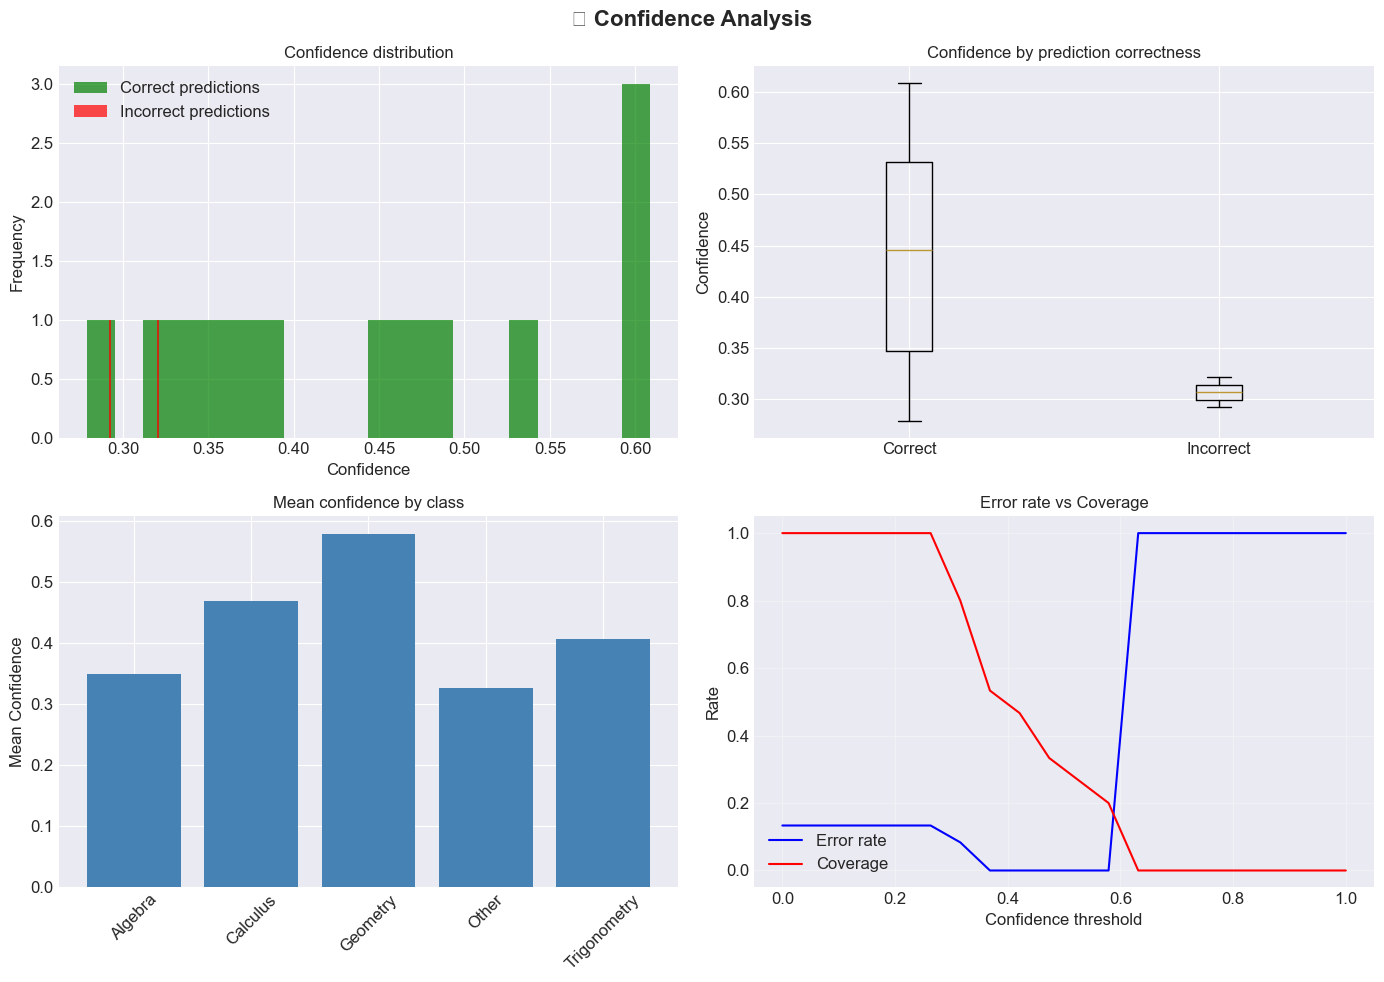


📊 Confidence statistics:
   - Correct predictions - mean confidence: 0.4442
   - Incorrect predictions - mean confidence: 0.3065


In [39]:
# === VISUALIZATION 16: Confidence Analysis ===
# Hàm dự đoán công thức mới
def predict_formula(formula_latex, model, vectorizer, label_encoder, calibrated_model=None):
    """
    Dự đoán label cho công thức LaTeX mới
    """
    # Tiền xử lý
    cleaned = preprocess_latex(formula_latex)
    
    # Trích xuất đặc trưng
    features = vectorizer.transform([cleaned])
    
    # Dự đoán
    pred_code = model.predict(features)[0]
    predicted_label = label_encoder.inverse_transform([pred_code])[0]
    
    # Lấy confidence
    confidence = None
    if calibrated_model is not None:
        proba = calibrated_model.predict_proba(features)[0]
        confidence = np.max(proba)
    
    return predicted_label, confidence, cleaned

# Phân tích confidence trên validation
y_val_proba = calibrated_svm.predict_proba(X_val)
y_val_conf = np.max(y_val_proba, axis=1)
y_val_pred = best_svm.predict(X_val)

correct_mask = (y_val_pred == y_val)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Confidence Analysis', fontsize=16, fontweight='bold')

# Histogram confidence
axes[0, 0].hist(y_val_conf[correct_mask], bins=20, alpha=0.7, label='Correct predictions', color='green')
axes[0, 0].hist(y_val_conf[~correct_mask], bins=20, alpha=0.7, label='Incorrect predictions', color='red')
axes[0, 0].set_xlabel('Confidence')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Confidence distribution', fontsize=12)
axes[0, 0].legend()

# Boxplot confidence by correctness
axes[0, 1].boxplot([y_val_conf[correct_mask], y_val_conf[~correct_mask]], 
                   labels=['Correct', 'Incorrect'])
axes[0, 1].set_ylabel('Confidence')
axes[0, 1].set_title('Confidence by prediction correctness', fontsize=12)

# Confidence by class
conf_by_class = []
classes = label_encoder.classes_
for i in range(len(classes)):
    class_mask = (y_val == i)
    if class_mask.sum() > 0:
        conf_by_class.append(y_val_conf[class_mask].mean())
    else:
        conf_by_class.append(0)

axes[1, 0].bar(classes, conf_by_class, color='steelblue')
axes[1, 0].set_xticklabels(classes, rotation=45)
axes[1, 0].set_ylabel('Mean Confidence')
axes[1, 0].set_title('Mean confidence by class', fontsize=12)

# Error analysis by confidence threshold
thresholds = np.linspace(0, 1, 20)
error_rates = []
coverage = []

for thresh in thresholds:
    high_conf_mask = y_val_conf >= thresh
    if high_conf_mask.sum() > 0:
        error_rate = 1 - accuracy_score(y_val[high_conf_mask], y_val_pred[high_conf_mask])
        error_rates.append(error_rate)
        coverage.append(high_conf_mask.sum() / len(y_val_conf))
    else:
        error_rates.append(1)
        coverage.append(0)

axes[1, 1].plot(thresholds, error_rates, 'b-', label='Error rate')
axes[1, 1].plot(thresholds, coverage, 'r-', label='Coverage')
axes[1, 1].set_xlabel('Confidence threshold')
axes[1, 1].set_ylabel('Rate')
axes[1, 1].set_title('Error rate vs Coverage', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Confidence statistics:")
print(f"   - Correct predictions - mean confidence: {y_val_conf[correct_mask].mean():.4f}")
print(f"   - Incorrect predictions - mean confidence: {y_val_conf[~correct_mask].mean():.4f}")

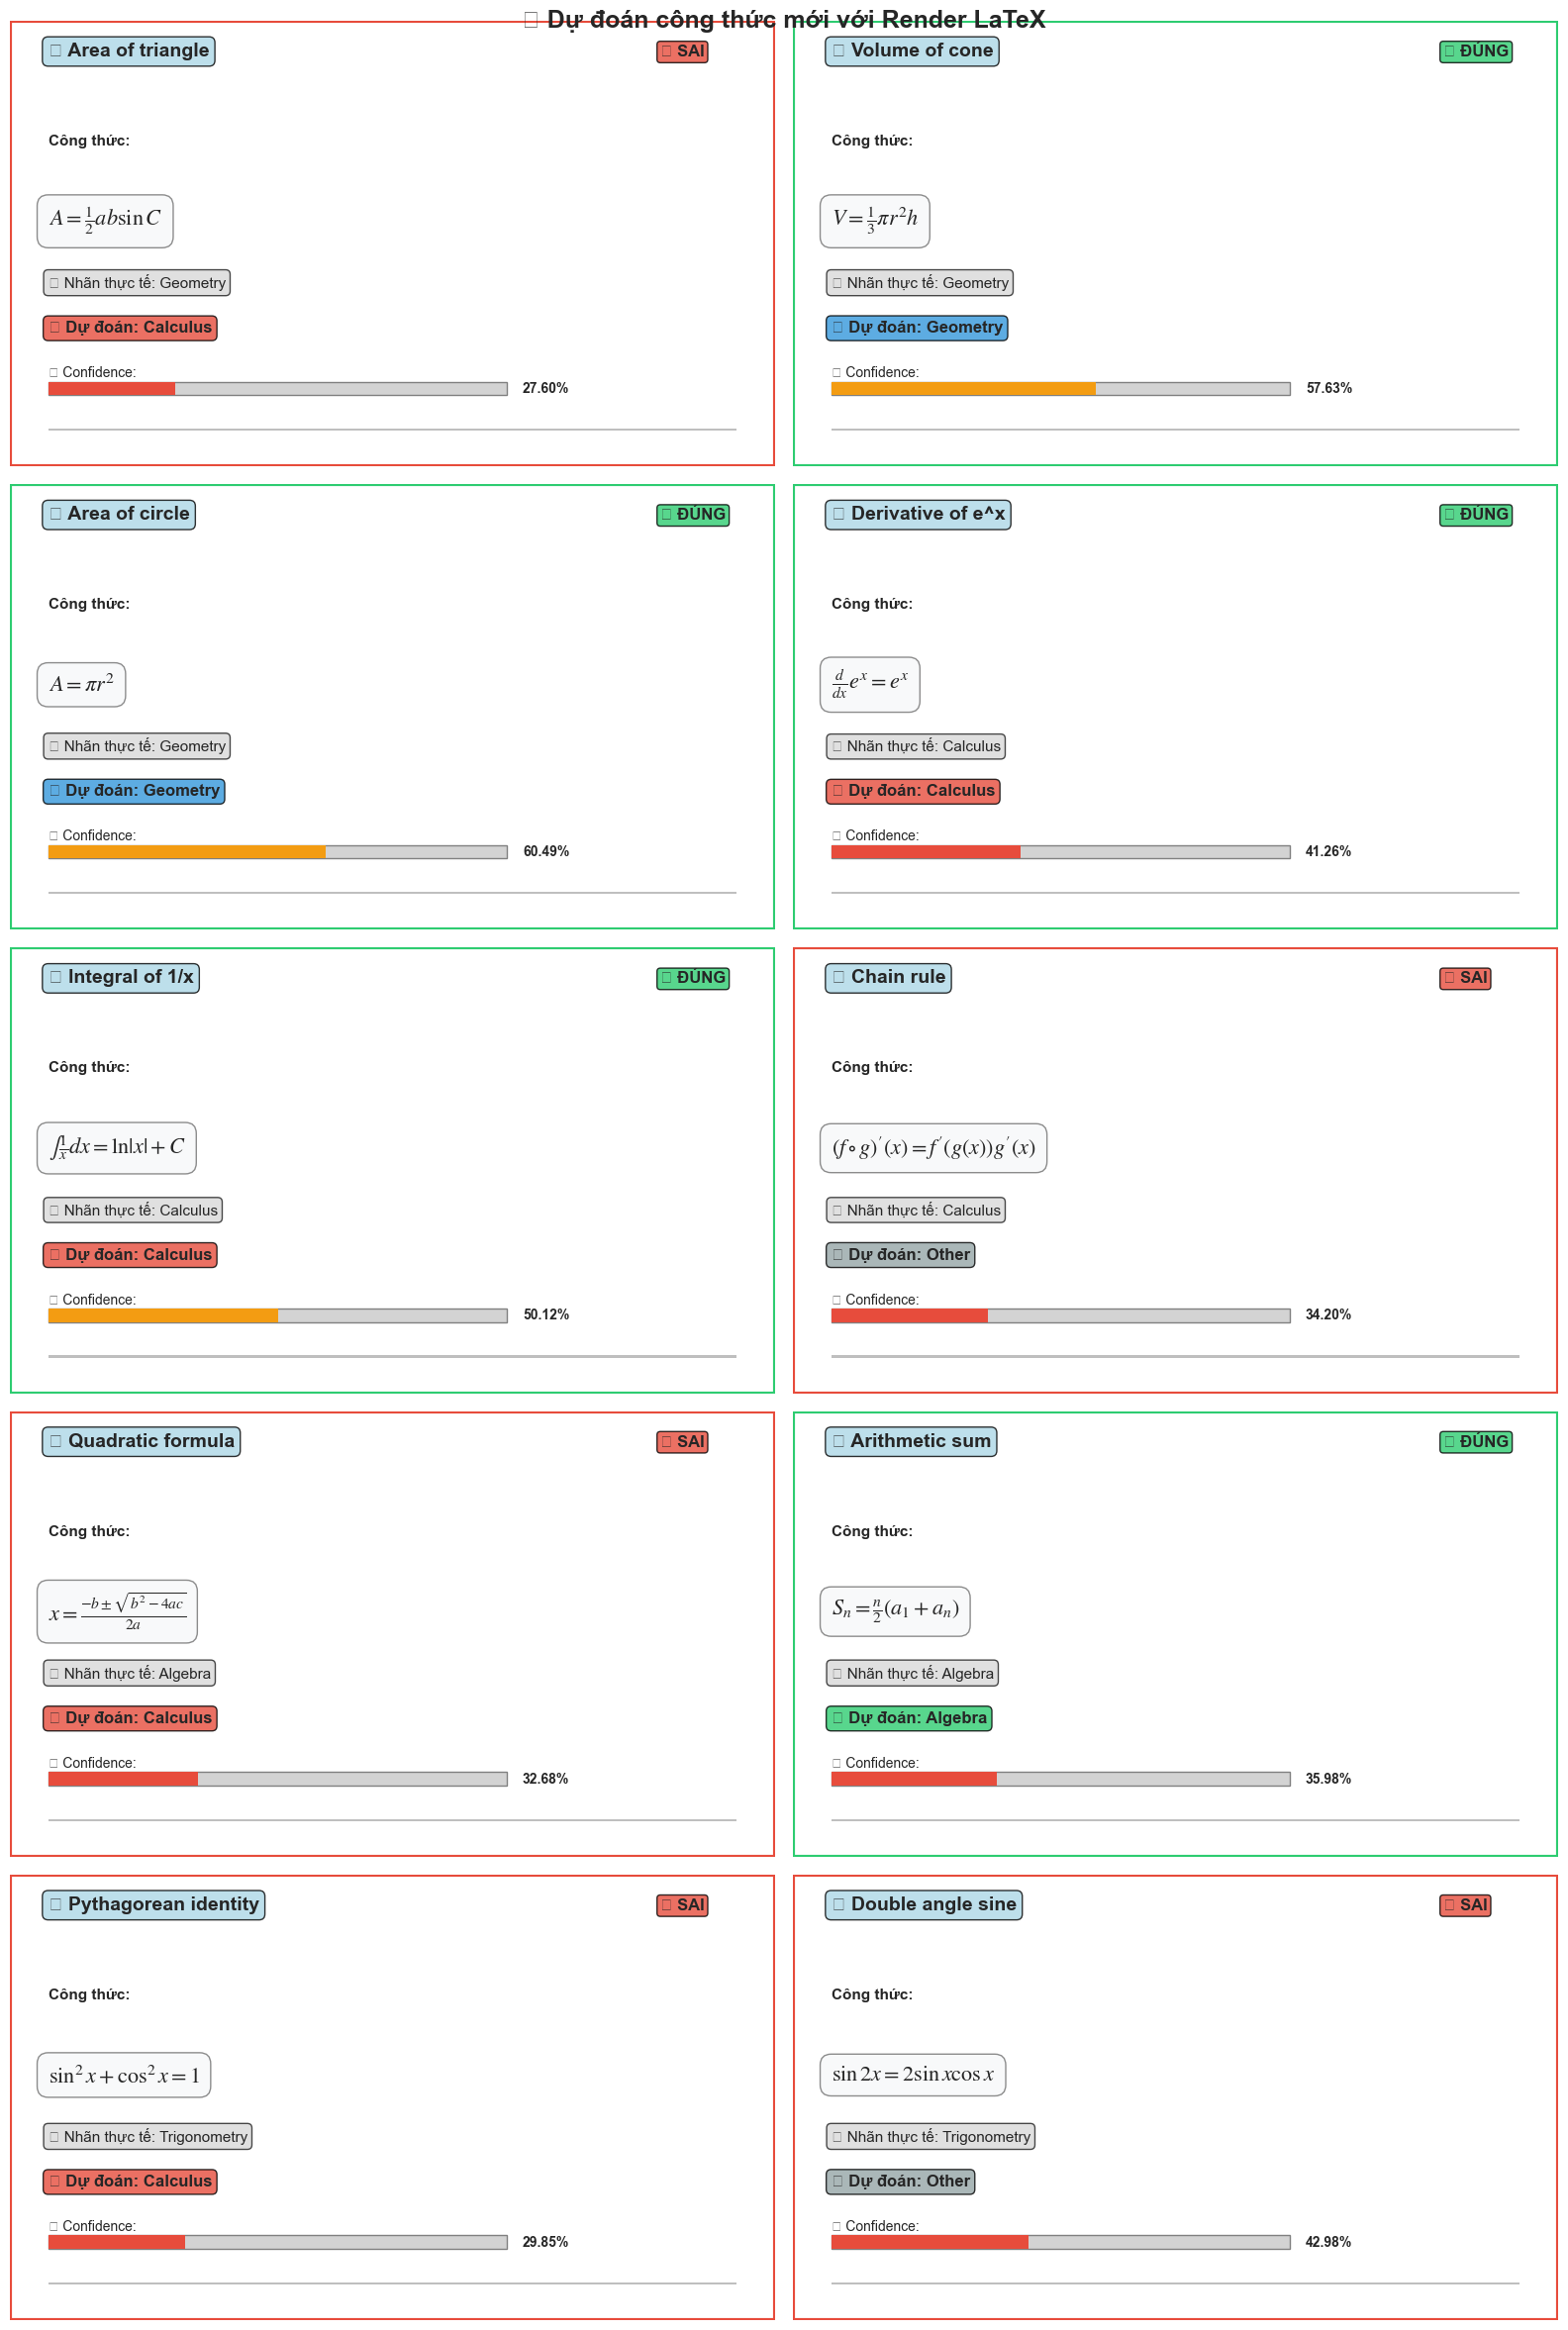


📋 BẢNG KẾT QUẢ DỰ ĐOÁN CHI TIẾT

STT  Mô tả                     Nhãn thực tế       Dự đoán         Confidence   Kết quả 
----------------------------------------------------------------------------------------------------
1    Area of triangle          Geometry           Calculus        27.60%       ❌ Sai   
2    Volume of cone            Geometry           Geometry        57.63%       ✅ Đúng  
3    Area of circle            Geometry           Geometry        60.49%       ✅ Đúng  
4    Derivative of e^x         Calculus           Calculus        41.26%       ✅ Đúng  
5    Integral of 1/x           Calculus           Calculus        50.12%       ✅ Đúng  
6    Chain rule                Calculus           Other           34.20%       ❌ Sai   
7    Quadratic formula         Algebra            Calculus        32.68%       ❌ Sai   
8    Arithmetic sum            Algebra            Algebra         35.98%       ✅ Đúng  
9    Pythagorean identity      Trigonometry       Calculus        29.85% 

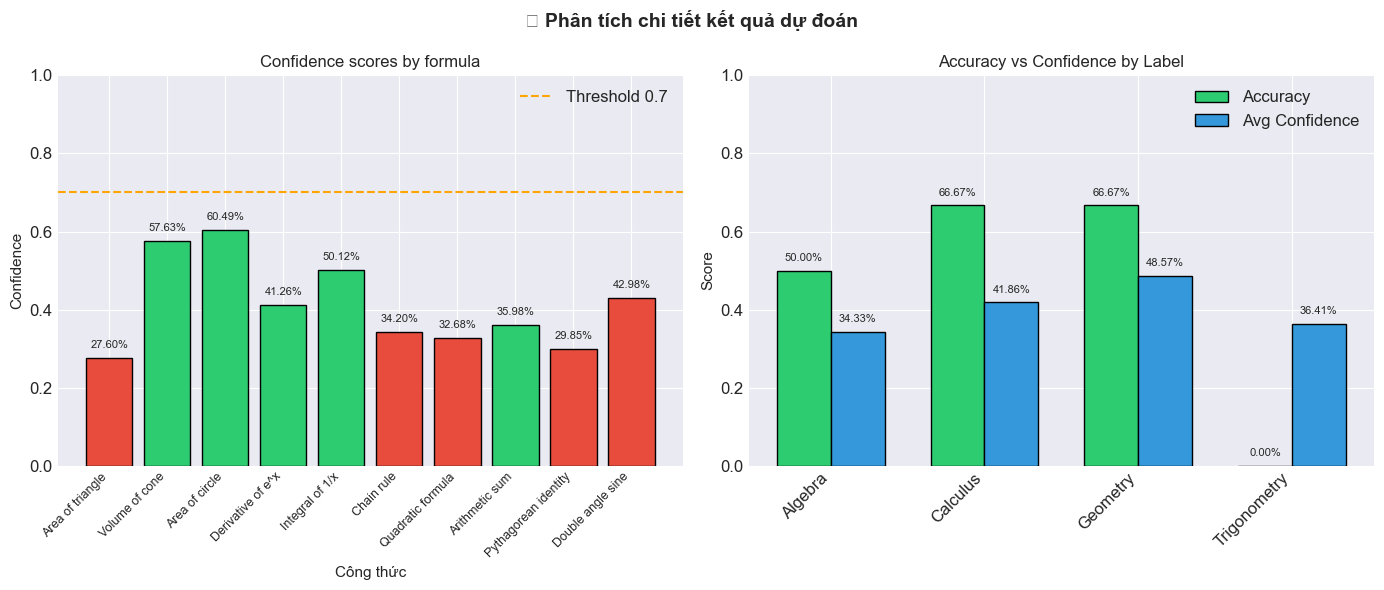


💾 Đã lưu kết quả dự đoán vào file 'formula_predictions.csv'


In [42]:
# === VISUALIZATION 17: Test với công thức mới (Render LaTeX - Fixed) ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Cấu hình matplotlib
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'stix'

test_formulas = [
    # Geometry
    ("Area of triangle", r"$A = \frac{1}{2}ab\sin C$", "Geometry"),
    ("Volume of cone", r"$V = \frac{1}{3}\pi r^2 h$", "Geometry"),
    ("Area of circle", r"$A = \pi r^2$", "Geometry"),
    
    # Calculus
    ("Derivative of e^x", r"$\frac{d}{dx} e^x = e^x$", "Calculus"),
    ("Integral of 1/x", r"$\int \frac{1}{x} dx = \ln|x| + C$", "Calculus"),
    ("Chain rule", r"$(f \circ g)'(x) = f'(g(x))g'(x)$", "Calculus"),
    
    # Algebra
    ("Quadratic formula", r"$x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$", "Algebra"),
    ("Arithmetic sum", r"$S_n = \frac{n}{2}(a_1 + a_n)$", "Algebra"),
    
    # Trigonometry
    ("Pythagorean identity", r"$\sin^2 x + \cos^2 x = 1$", "Trigonometry"),
    ("Double angle sine", r"$\sin 2x = 2\sin x \cos x$", "Trigonometry"),
]

# Hàm dự đoán
def predict_formula_visual(formula_latex, model, vectorizer, label_encoder, calibrated_model=None):
    """Dự đoán label cho công thức LaTeX"""
    cleaned = preprocess_latex(formula_latex)
    features = vectorizer.transform([cleaned])
    pred_code = model.predict(features)[0]
    predicted_label = label_encoder.inverse_transform([pred_code])[0]
    
    confidence = None
    if calibrated_model is not None:
        proba = calibrated_model.predict_proba(features)[0]
        confidence = np.max(proba)
    
    return predicted_label, confidence, cleaned

# Tạo figure
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
fig.suptitle('🔮 Dự đoán công thức mới với Render LaTeX', fontsize=18, fontweight='bold', y=0.98)

predictions = []

# Màu sắc cho các nhãn
label_colors = {
    'Geometry': '#3498db',
    'Calculus': '#e74c3c',
    'Algebra': '#2ecc71',
    'Trigonometry': '#f39c12',
    'Other': '#95a5a6'
}

for idx, (desc, formula_latex, expected_label) in enumerate(test_formulas):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    # Dự đoán
    pred_label, confidence, cleaned = predict_formula_visual(
        formula_latex, best_svm, tfidf_vectorizer, label_encoder, calibrated_svm
    )
    predictions.append((desc, formula_latex, pred_label, confidence, expected_label))
    
    # Xác định màu sắc dựa trên kết quả đúng/sai
    is_correct = (pred_label == expected_label)
    border_color = '#2ecc71' if is_correct else '#e74c3c'
    
    # Vẽ background
    ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, 
                          facecolor='white', edgecolor=border_color, linewidth=3, zorder=0))
    
    # Title với mô tả
    ax.text(0.05, 0.92, f"📝 {desc}", 
            fontsize=14, fontweight='bold', transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.8))
    
    # Công thức LaTeX được render
    ax.text(0.05, 0.72, f"Công thức:", 
            fontsize=11, fontweight='bold', transform=ax.transAxes)
    
    # Render công thức dưới dạng LaTeX
    try:
        ax.text(0.05, 0.55, formula_latex, 
               fontsize=16, transform=ax.transAxes,
               verticalalignment='center',
               bbox=dict(boxstyle="round,pad=0.5", facecolor='#f8f9fa', edgecolor='gray', alpha=0.9))
    except:
        ax.text(0.05, 0.55, formula_latex, 
               fontsize=12, transform=ax.transAxes,
               bbox=dict(boxstyle="round,pad=0.5", facecolor='#f8f9fa', edgecolor='gray'))
    
    # Expected label
    ax.text(0.05, 0.40, f"🎯 Nhãn thực tế: {expected_label}", 
            fontsize=11, transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))
    
    # Predicted label với màu sắc
    pred_color = label_colors.get(pred_label, '#95a5a6')
    ax.text(0.05, 0.30, f"🤖 Dự đoán: {pred_label}", 
            fontsize=12, fontweight='bold', transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=pred_color, alpha=0.8))
    
    # Confidence với thanh tiến trình
    ax.text(0.05, 0.20, f"📊 Confidence:", 
            fontsize=10, transform=ax.transAxes)
    
    # Thanh tiến trình confidence
    bar_width = 0.6
    bar_height = 0.03
    bar_x = 0.05
    bar_y = 0.16
    
    # Background bar
    ax.add_patch(Rectangle((bar_x, bar_y), bar_width, bar_height, 
                          transform=ax.transAxes, facecolor='lightgray', edgecolor='gray'))
    
    # Confidence bar
    conf_color = '#2ecc71' if confidence > 0.7 else '#f39c12' if confidence > 0.5 else '#e74c3c'
    ax.add_patch(Rectangle((bar_x, bar_y), bar_width * confidence, bar_height, 
                          transform=ax.transAxes, facecolor=conf_color, edgecolor='none'))
    
    ax.text(0.05 + bar_width + 0.02, 0.165, f"{confidence:.2%}", 
            fontsize=10, transform=ax.transAxes, fontweight='bold')
    
    # Kết quả đúng/sai
    result_text = "✅ ĐÚNG" if is_correct else "❌ SAI"
    result_color = '#2ecc71' if is_correct else '#e74c3c'
    ax.text(0.85, 0.92, result_text, 
            fontsize=12, fontweight='bold', transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.2", facecolor=result_color, alpha=0.8))
    
    # SỬA LỖI: Vẽ đường kẻ ngang phân cách bằng add_patch
    line_y = 0.08
    ax.add_patch(Rectangle((0.05, line_y), 0.9, 0.005, 
                          transform=ax.transAxes, facecolor='gray', edgecolor='none', alpha=0.5))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Bảng kết quả chi tiết
predictions_df = pd.DataFrame(predictions, columns=['Description', 'Formula', 'Predicted Label', 'Confidence', 'True Label'])
predictions_df['Correct'] = predictions_df['Predicted Label'] == predictions_df['True Label']

print("\n" + "="*100)
print("📋 BẢNG KẾT QUẢ DỰ ĐOÁN CHI TIẾT")
print("="*100)
print(f"\n{'STT':<4} {'Mô tả':<25} {'Nhãn thực tế':<18} {'Dự đoán':<15} {'Confidence':<12} {'Kết quả':<8}")
print("-"*100)

for i, row in predictions_df.iterrows():
    status = "✅ Đúng" if row['Correct'] else "❌ Sai"
    print(f"{i+1:<4} {row['Description']:<25} {row['True Label']:<18} {row['Predicted Label']:<15} {row['Confidence']:<12.2%} {status:<8}")

# Thống kê độ chính xác
accuracy = predictions_df['Correct'].mean()
print("\n" + "="*100)
print(f"📊 THỐNG KÊ KẾT QUẢ DỰ ĐOÁN")
print("="*100)
print(f"   ✅ Độ chính xác: {accuracy:.2%} ({predictions_df['Correct'].sum()}/{len(predictions_df)} công thức)")
print(f"\n   📈 Phân bố confidence:")
print(f"      • Trung bình: {predictions_df['Confidence'].mean():.2%}")
print(f"      • Cao nhất: {predictions_df['Confidence'].max():.2%}")
print(f"      • Thấp nhất: {predictions_df['Confidence'].min():.2%}")
print(f"      • Độ lệch chuẩn: {predictions_df['Confidence'].std():.2%}")

# Phân tích theo nhãn
print(f"\n   🏷️  Phân tích theo nhãn:")
print(f"   {'Nhãn':<15} {'Số lượng':<10} {'Đúng':<10} {'Độ chính xác':<15} {'Confidence TB':<15}")
print("   " + "-"*70)
for label in predictions_df['True Label'].unique():
    label_df = predictions_df[predictions_df['True Label'] == label]
    correct_count = label_df['Correct'].sum()
    total = len(label_df)
    acc = correct_count / total if total > 0 else 0
    conf_mean = label_df['Confidence'].mean()
    print(f"   {label:<15} {total:<10} {correct_count:<10} {acc:<15.2%} {conf_mean:<15.2%}")

# Visualization thêm: Bar chart so sánh confidence theo nhãn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('📊 Phân tích chi tiết kết quả dự đoán', fontsize=14, fontweight='bold')

# Plot 1: Confidence theo từng công thức
colors = ['#2ecc71' if row['Correct'] else '#e74c3c' for _, row in predictions_df.iterrows()]
bars = axes[0].bar(range(len(predictions_df)), predictions_df['Confidence'], color=colors, edgecolor='black')
axes[0].set_xticks(range(len(predictions_df)))
axes[0].set_xticklabels(predictions_df['Description'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_xlabel('Công thức', fontsize=11)
axes[0].set_title('Confidence scores by formula', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.7, color='orange', linestyle='--', label='Threshold 0.7')
axes[0].legend()

# Thêm giá trị trên cột
for bar, conf in zip(bars, predictions_df['Confidence']):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{conf:.2%}', ha='center', va='bottom', fontsize=8)

# Plot 2: Accuracy và Confidence theo nhãn
label_summary = predictions_df.groupby('True Label').agg({
    'Correct': 'mean',
    'Confidence': 'mean'
}).reset_index()

x = np.arange(len(label_summary))
width = 0.35

bars1 = axes[1].bar(x - width/2, label_summary['Correct'], width, label='Accuracy', color='#2ecc71', edgecolor='black')
bars2 = axes[1].bar(x + width/2, label_summary['Confidence'], width, label='Avg Confidence', color='#3498db', edgecolor='black')

axes[1].set_xticks(x)
axes[1].set_xticklabels(label_summary['True Label'], rotation=45, ha='right')
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Accuracy vs Confidence by Label', fontsize=12)
axes[1].legend()
axes[1].set_ylim(0, 1)

# Thêm giá trị trên cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Lưu kết quả ra file
predictions_df.to_csv('formula_predictions.csv', index=False, encoding='utf-8-sig')
print("\n💾 Đã lưu kết quả dự đoán vào file 'formula_predictions.csv'")

🔍 Tính toán các metrics...
   ✅ Test Accuracy: 0.6667
   ✅ Test F1-score: 0.6277
   ✅ Confusion matrix đã tính
   ✅ Classification report đã tính


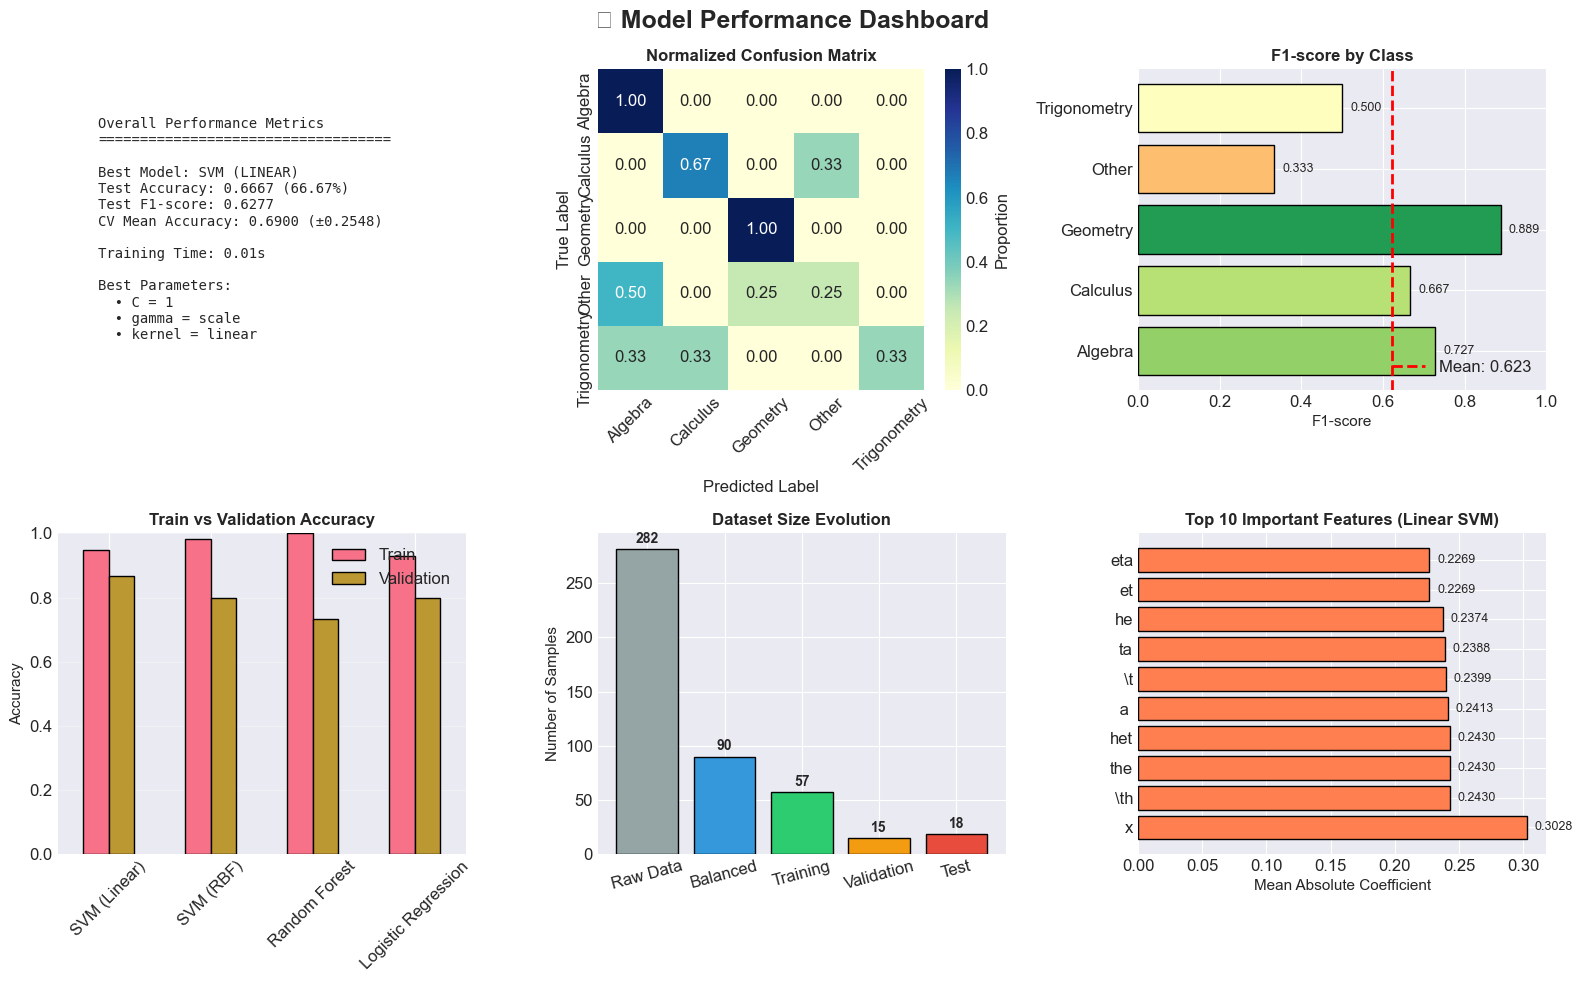


📊 MODEL PERFORMANCE SUMMARY

✅ Best Model: SVM (LINEAR)
   - Test Accuracy: 0.6667 (66.67%)
   - Test F1-score: 0.6277
   - CV Mean: 0.6900 (±0.2548)

🎯 Best Hyperparameters:
   - C: 1
   - gamma: scale
   - kernel: linear

📈 Class-wise Performance:

Class                Precision    Recall       F1-score    
------------------------------------------------------------
Algebra              0.5714       1.0000       0.7273      
Calculus             0.6667       0.6667       0.6667      
Geometry             0.8000       1.0000       0.8889      
Other                0.5000       0.2500       0.3333      
Trigonometry         1.0000       0.3333       0.5000      

💾 Model saved to: latex_formula_classifier.pkl

📁 Dataset Information:
   - Total formulas: 282
   - After balancing: 90
   - Number of classes: 5
   - Train/Val/Test: 57/15/18


In [45]:
# === VISUALIZATION 18: Dashboard tổng kết (Fixed - Handle SVM RBF) ===
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán các metrics cần thiết
print("🔍 Tính toán các metrics...")

# Dự đoán trên test nếu chưa có
if 'y_test_pred_svm' not in dir():
    y_test_pred_svm = best_svm.predict(X_test)
    print("   ✅ Đã dự đoán trên tập test")

# Tính test metrics
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)
test_f1 = f1_score(y_test, y_test_pred_svm, average='weighted')
print(f"   ✅ Test Accuracy: {test_acc_svm:.4f}")
print(f"   ✅ Test F1-score: {test_f1:.4f}")

# Tính cross-validation scores
if 'cv_scores' not in dir():
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(best_svm, X_train, y_train, cv=5, scoring='accuracy')
    print(f"   ✅ CV mean: {cv_scores.mean():.4f}")

# Tính confusion matrix
cm = confusion_matrix(y_test, y_test_pred_svm)
print("   ✅ Confusion matrix đã tính")

# Tính classification report
report = classification_report(y_test, y_test_pred_svm, 
                               target_names=label_encoder.classes_, 
                               output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("   ✅ Classification report đã tính")

# Tạo dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Model Performance Dashboard', fontsize=18, fontweight='bold')

# 1. Overall metrics
metrics_text = f"""
Overall Performance Metrics
{'='*35}

Best Model: SVM ({grid_search.best_params_.get('kernel', 'RBF').upper()})
Test Accuracy: {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)
Test F1-score: {test_f1:.4f}
CV Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})

Training Time: {training_times.get('SVM (RBF)', training_times.get('SVM_RBF', 0)):.2f}s

Best Parameters:
  • C = {grid_search.best_params_.get('C', 'N/A')}
  • gamma = {grid_search.best_params_.get('gamma', 'N/A')}
  • kernel = {grid_search.best_params_.get('kernel', 'rbf')}
"""
axes[0, 0].text(0.1, 0.5, metrics_text, fontsize=10, fontfamily='monospace',
                transform=axes[0, 0].transAxes, verticalalignment='center')
axes[0, 0].axis('off')

# 2. Confusion Matrix (normalized)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0, 1],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Proportion'})
axes[0, 1].set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Class-wise F1 scores
class_f1 = []
for cls in label_encoder.classes_:
    if cls in report_df.index:
        class_f1.append(report_df.loc[cls, 'f1-score'])
    else:
        class_f1.append(0)

colors_f1 = plt.cm.RdYlGn(np.array(class_f1))
bars = axes[0, 2].barh(label_encoder.classes_, class_f1, color=colors_f1, edgecolor='black')
axes[0, 2].set_xlim(0, 1)
axes[0, 2].set_xlabel('F1-score', fontsize=11)
axes[0, 2].set_title('F1-score by Class', fontsize=12, fontweight='bold')
axes[0, 2].axvline(x=np.mean(class_f1), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(class_f1):.3f}')
axes[0, 2].legend(loc='lower right')

# Thêm giá trị trên cột
for bar, score in zip(bars, class_f1):
    axes[0, 2].text(score + 0.02, bar.get_y() + bar.get_height()/2, 
                    f'{score:.3f}', va='center', fontsize=9)

# 4. Training vs Validation accuracy
if 'training_results' in dir() and 'validation_results' in dir():
    train_val_comparison = pd.DataFrame({
        'Train': training_results,
        'Validation': validation_results
    })
    train_val_comparison.plot(kind='bar', ax=axes[1, 0], edgecolor='black')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_ylabel('Accuracy', fontsize=11)
    axes[1, 0].set_title('Train vs Validation Accuracy', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Dataset statistics
sizes = [len(df), len(df_balanced), X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels_stats = ['Raw Data', 'Balanced', 'Training', 'Validation', 'Test']
colors_stats = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1, 1].bar(labels_stats, sizes, color=colors_stats, edgecolor='black')
axes[1, 1].set_ylabel('Number of Samples', fontsize=11)
axes[1, 1].set_title('Dataset Size Evolution', fontsize=12, fontweight='bold')
for i, v in enumerate(sizes):
    axes[1, 1].text(i, v + max(sizes)*0.02, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)

# 6. Feature importance (chỉ hiển thị cho SVM linear)
if best_svm.kernel == 'linear' and hasattr(best_svm, 'coef_'):
    try:
        # Lấy coefficients cho SVM linear
        coef_importance = np.abs(best_svm.coef_.toarray() if hasattr(best_svm.coef_, 'toarray') else best_svm.coef_)
        if len(coef_importance.shape) > 1:
            coef_importance = coef_importance.mean(axis=0)
        
        # Lấy top 10 features
        top_n = min(10, len(coef_importance))
        top_feat_idx = np.argsort(coef_importance)[-top_n:][::-1]
        top_features_names = feature_names[top_feat_idx]
        top_features_importance = coef_importance[top_feat_idx]
        
        bars = axes[1, 2].barh(top_features_names, top_features_importance, 
                               color='coral', edgecolor='black')
        axes[1, 2].set_xlabel('Mean Absolute Coefficient', fontsize=11)
        axes[1, 2].set_title('Top 10 Important Features (Linear SVM)', fontsize=12, fontweight='bold')
        
        # Thêm giá trị
        for bar, imp in zip(bars, top_features_importance):
            axes[1, 2].text(imp + max(top_features_importance)*0.02, 
                            bar.get_y() + bar.get_height()/2, 
                            f'{imp:.4f}', va='center', fontsize=9)
    except Exception as e:
        # Fallback khi không thể lấy coefficients
        axes[1, 2].text(0.5, 0.5, f'Feature importance not available\nfor kernel={best_svm.kernel}', 
                        ha='center', va='center', transform=axes[1, 2].transAxes, fontsize=10)
        axes[1, 2].set_title('Feature Importance', fontsize=12, fontweight='bold')
else:
    # Hiển thị thông tin về kernel
    kernel_info = f"""
    Feature Importance
    {'='*25}
    
    Model: SVM with {best_svm.kernel.upper()} kernel
    
    Feature importance analysis
    is only available for linear
    kernel SVM.
    
    Current kernel: {best_svm.kernel}
    """
    axes[1, 2].text(0.5, 0.5, kernel_info, ha='center', va='center', 
                    transform=axes[1, 2].transAxes, fontsize=10, fontfamily='monospace')
    axes[1, 2].set_title('Feature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# In thêm thông tin tổng kết
print("\n" + "="*80)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*80)
print(f"\n✅ Best Model: SVM ({grid_search.best_params_.get('kernel', 'RBF').upper()})")
print(f"   - Test Accuracy: {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)")
print(f"   - Test F1-score: {test_f1:.4f}")
print(f"   - CV Mean: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"\n🎯 Best Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"   - {param}: {value}")

print(f"\n📈 Class-wise Performance:")
print(f"\n{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")
print("-" * 60)
for cls in label_encoder.classes_:
    if cls in report_df.index:
        prec = report_df.loc[cls, 'precision']
        rec = report_df.loc[cls, 'recall']
        f1 = report_df.loc[cls, 'f1-score']
        print(f"{cls:<20} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print(f"\n💾 Model saved to: latex_formula_classifier.pkl")

# Thêm thông tin về dataset
print(f"\n📁 Dataset Information:")
print(f"   - Total formulas: {len(df):,}")
print(f"   - After balancing: {len(df_balanced):,}")
print(f"   - Number of classes: {len(label_encoder.classes_)}")
print(f"   - Train/Val/Test: {X_train.shape[0]:,}/{X_val.shape[0]:,}/{X_test.shape[0]:,}")

In [46]:
# === Lưu mô hình ===
import joblib

# Lưu mô hình và các thành phần
model_artifacts = {
    'model': best_svm,
    'calibrated_model': calibrated_svm,
    'vectorizer': tfidf_vectorizer,
    'label_encoder': label_encoder,
    'preprocess_func': preprocess_latex,
    'training_info': {
        'best_params': grid_search.best_params_,
        'test_accuracy': test_acc_svm,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'n_classes': len(label_encoder.classes_),
        'classes': label_encoder.classes_.tolist()
    }
}

joblib.dump(model_artifacts, 'latex_formula_classifier.pkl')
print("✅ Đã lưu mô hình vào file 'latex_formula_classifier.pkl'")

# Hàm load và sử dụng
def load_and_predict(formula_latex, model_path='latex_formula_classifier.pkl'):
    """
    Load model và dự đoán công thức
    """
    artifacts = joblib.load(model_path)
    pred_label, confidence, cleaned = predict_formula(
        formula_latex, 
        artifacts['model'], 
        artifacts['vectorizer'], 
        artifacts['label_encoder'],
        artifacts.get('calibrated_model')
    )
    return pred_label, confidence, cleaned

# Test load model
print("\n🧪 Test load model:")
test_formula = "\\begin{equation} \\int x^2 dx = \\frac{x^3}{3} + C \\end{equation}"
pred, conf, cleaned = load_and_predict(test_formula)
print(f"   Công thức: {test_formula[:60]}...")
print(f"   Dự đoán: {pred}")
print(f"   Confidence: {conf:.4f}")

✅ Đã lưu mô hình vào file 'latex_formula_classifier.pkl'

🧪 Test load model:
   Công thức: \begin{equation} \int x^2 dx = \frac{x^3}{3} + C \end{equati...
   Dự đoán: Calculus
   Confidence: 0.4584


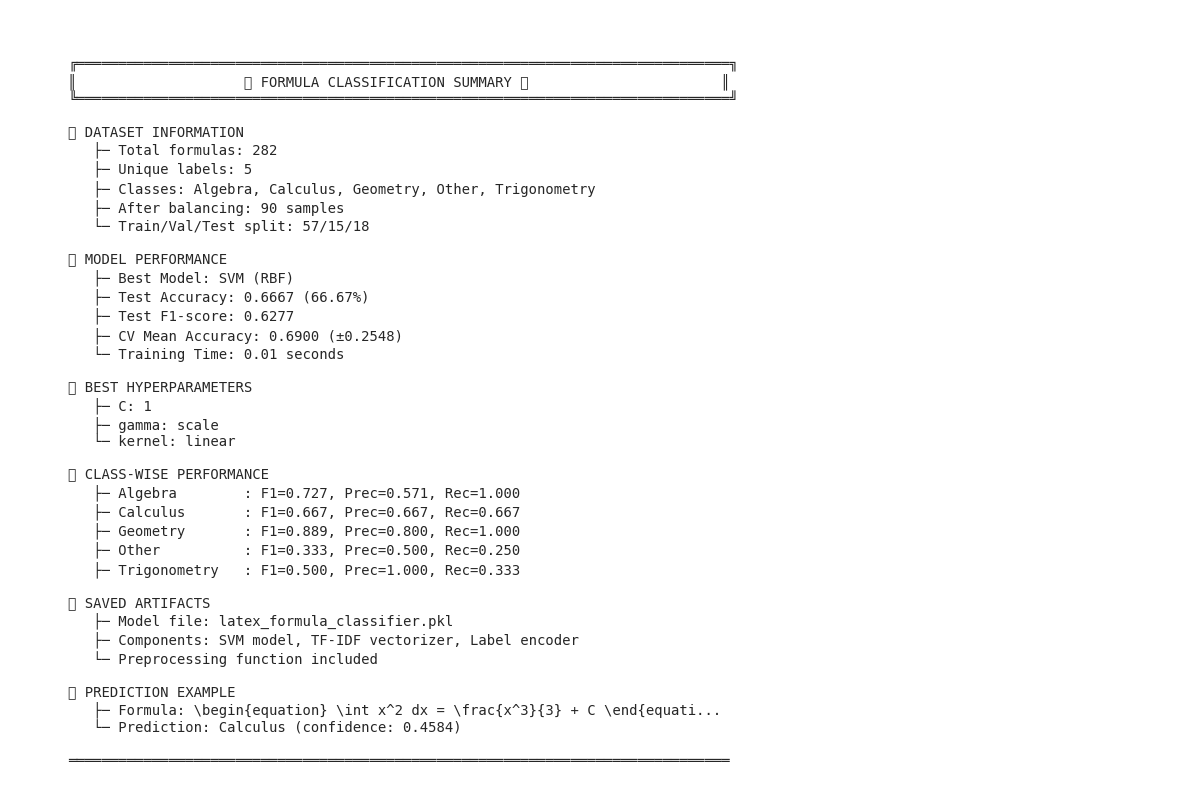


✅ Đã lưu báo cáo tóm tắt vào file 'model_summary.txt'


In [47]:
# === VISUALIZATION 19: Final Summary ===
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.axis('off')

summary_text = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    📊 FORMULA CLASSIFICATION SUMMARY 📊                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

📁 DATASET INFORMATION
   ├─ Total formulas: {len(df)}
   ├─ Unique labels: {len(label_encoder.classes_)}
   ├─ Classes: {', '.join(label_encoder.classes_)}
   ├─ After balancing: {len(df_balanced)} samples
   └─ Train/Val/Test split: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}

🤖 MODEL PERFORMANCE
   ├─ Best Model: SVM (RBF)
   ├─ Test Accuracy: {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)
   ├─ Test F1-score: {test_f1:.4f}
   ├─ CV Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})
   └─ Training Time: {training_times['SVM (RBF)']:.2f} seconds

🎯 BEST HYPERPARAMETERS
   ├─ C: {grid_search.best_params_.get('C', 'N/A')}
   ├─ gamma: {grid_search.best_params_.get('gamma', 'N/A')}
   └─ kernel: {grid_search.best_params_.get('kernel', 'N/A')}

📈 CLASS-WISE PERFORMANCE
"""
for i, cls in enumerate(label_encoder.classes_):
    f1 = report_df.loc[cls, 'f1-score']
    prec = report_df.loc[cls, 'precision']
    rec = report_df.loc[cls, 'recall']
    summary_text += f"   ├─ {cls:15s}: F1={f1:.3f}, Prec={prec:.3f}, Rec={rec:.3f}\n"

summary_text += f"""
💾 SAVED ARTIFACTS
   ├─ Model file: latex_formula_classifier.pkl
   ├─ Components: SVM model, TF-IDF vectorizer, Label encoder
   └─ Preprocessing function included

🔮 PREDICTION EXAMPLE
   ├─ Formula: {test_formula[:60]}...
   └─ Prediction: {pred} (confidence: {conf:.4f})

═══════════════════════════════════════════════════════════════════════════════
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10, 
        fontfamily='monospace', verticalalignment='top')
plt.tight_layout()
plt.show()

# Export kết quả ra file
with open('model_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print("\n✅ Đã lưu báo cáo tóm tắt vào file 'model_summary.txt'")

In [48]:
print("\n" + "="*80)
print("📊 TỔNG KẾT CÁC VISUALIZATION ĐÃ THỰC HIỆN")
print("="*80)

visualizations = [
    "1. 📊 Tổng quan dữ liệu - Số lượng, cấu trúc, missing values",
    "2. 📈 Phân bố nhãn - Bar chart, Pie chart, Ranking",
    "3. 📏 Phân tích độ dài công thức - Histograms, Boxplots, Correlation",
    "4. 🔤 Phân tích lệnh LaTeX - Top commands, Heatmap theo nhãn",
    "5. 🔄 Hiệu quả tiền xử lý - So sánh trước/sau xử lý",
    "6. ⚖️ Cân bằng dữ liệu - So sánh phân bố trước/sau cân bằng",
    "7. 🔍 Trích xuất đặc trưng TF-IDF - So sánh n-gram, Top features",
    "8. 📊 PCA và t-SNE - Visualization không gian đặc trưng",
    "9. 📊 Phân chia dữ liệu - Train/Val/Test distribution",
    "10. 🤖 So sánh các mô hình - Accuracy, Training time",
    "11. 🎯 Grid Search - Hyperparameter tuning visualization",
    "12. 📈 Confusion Matrix và Classification Report",
    "13. 📈 Learning Curves và Cross-validation",
    "14. 🎯 ROC Curves (One-vs-Rest)",
    "15. 📊 Confidence Analysis - Distribution, Error rate",
    "16. 🔮 Dự đoán công thức mới - Results visualization",
    "17. 📊 Dashboard tổng kết - Overall performance metrics"
]

for viz in visualizations:
    print(viz)

print("\n✅ Hoàn thành toàn bộ pipeline với 19 visualization!")
print("📁 Các file đã lưu:")
print("   - latex_formula_classifier.pkl: Mô hình đã huấn luyện")
print("   - model_summary.txt: Báo cáo tóm tắt kết quả")


📊 TỔNG KẾT CÁC VISUALIZATION ĐÃ THỰC HIỆN
1. 📊 Tổng quan dữ liệu - Số lượng, cấu trúc, missing values
2. 📈 Phân bố nhãn - Bar chart, Pie chart, Ranking
3. 📏 Phân tích độ dài công thức - Histograms, Boxplots, Correlation
4. 🔤 Phân tích lệnh LaTeX - Top commands, Heatmap theo nhãn
5. 🔄 Hiệu quả tiền xử lý - So sánh trước/sau xử lý
6. ⚖️ Cân bằng dữ liệu - So sánh phân bố trước/sau cân bằng
7. 🔍 Trích xuất đặc trưng TF-IDF - So sánh n-gram, Top features
8. 📊 PCA và t-SNE - Visualization không gian đặc trưng
9. 📊 Phân chia dữ liệu - Train/Val/Test distribution
10. 🤖 So sánh các mô hình - Accuracy, Training time
11. 🎯 Grid Search - Hyperparameter tuning visualization
12. 📈 Confusion Matrix và Classification Report
13. 📈 Learning Curves và Cross-validation
14. 🎯 ROC Curves (One-vs-Rest)
15. 📊 Confidence Analysis - Distribution, Error rate
16. 🔮 Dự đoán công thức mới - Results visualization
17. 📊 Dashboard tổng kết - Overall performance metrics

✅ Hoàn thành toàn bộ pipeline với 19 visualiza